See [fast_phoenix_mlp_timing.ipynb](fast_phoenix_mlp_timing.ipynb) for starting points

In [1]:
import timeit
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np

from matplotlib import pyplot as plt
from IPython import display

from astropy import units as u
from astropy.io import fits
from astropy import constants as cnst

from astropy import visualization as viz
viz.quantity_support()

from jwst import datamodels

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import equinox as eqx
import optax

jax.devices()

[CudaDevice(id=0)]

# Data Loading

See [fast_phoenix_transformerpayne.ipynb](fast_phoenix_transformerpayne.ipynb) for details

In [2]:
phoenix_path = Path('../phoenix/fullgrid')

allspec = list(phoenix_path.glob('*.fits'))
wavepaths = [path for path in allspec if 'WAVE' in path.name]
assert len(wavepaths) == 1

with fits.open(wavepaths[0]) as f:
    wavehdu = f[0]
    ph_wave = wavehdu.data << u.Unit(wavehdu.header['UNIT'])


allspec = [path for path in allspec if 'WAVE' not in path.name]
len(allspec)

7559

In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

y, x = np.indices(slit.data.shape)
sky, spec = swcs.pixel_to_world(x, y)
densespec = np.linspace(np.nanmin(spec), np.nanmax(spec), x.shape[-1]*3)

In [4]:
class PhoenixResampler:
    def __init__(self, target_spacing, ph_wave, densespec):
        self.target_spacing = target_spacing
        msk = (densespec[0] < ph_wave) & (ph_wave < densespec[-1])
        self.resample_factor = int(round(target_spacing/np.max(np.diff(ph_wave[msk].to(u.angstrom)))))
        self.resample_msk = (densespec[0] < ph_wave) & (ph_wave < (densespec[-1]+target_spacing))
        self.cutoff_len = int(np.sum(self.resample_msk)/self.resample_factor)*self.resample_factor
        self.wave = self.subsample_data(ph_wave)

    def subsample_data(self, data):
        diced = data[self.resample_msk][:self.cutoff_len].reshape(-1, self.resample_factor)
        res = diced.mean(axis=1) 
        if hasattr(data, 'unit'):
            res = res << data.unit
        return res

phoenix_resampler = PhoenixResampler(0.5*u.angstrom, ph_wave, densespec)
resampled_wave = phoenix_resampler.wave
resampled_wave.shape

(8945,)

In [5]:
resampled_models = []
metas = defaultdict(list)
for path in tqdm(allspec):
    with fits.open(path) as f:
        resampled_models.append(phoenix_resampler.subsample_data(f[0].data))
        for key in ['PHXTEFF', 'PHXLOGG', 'PHXM_H', 'PHXALPHA']:
            metas[key].append(f[0].header[key])

stellar_models = jnp.array(resampled_models, dtype=jnp.float32)
stellar_metas = dict(metas)

assert len(set(stellar_metas['PHXALPHA'])) == 1 # only alpha/fe = 0 for this dataset

assert len(next(iter(metas.values()))) == stellar_models.shape[0]
stellar_models.shape

  0%|          | 0/7559 [00:00<?, ?it/s]

(7559, 8945)

In [6]:
stellar_parameter_names= ['PHXTEFF', 'PHXLOGG', 'PHXM_H']
stellar_parameter_arrs = jnp.array([stellar_metas[k] for k in stellar_parameter_names]).T
stellar_parameter_arrs.shape

(7559, 3)

Also lets identify a model for examination purposes thats vaguely sun-like

Array(4168, dtype=int32)

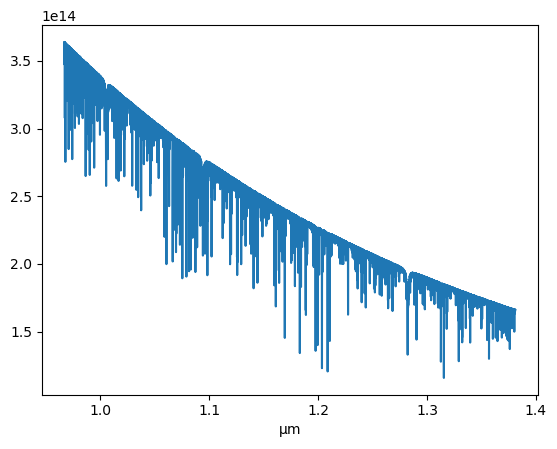

In [7]:
sunlike_idx = jnp.where((stellar_parameter_arrs[:, 0] == 5800)&(stellar_parameter_arrs[:, 1] == 4.5)&(stellar_parameter_arrs[:, 2] == 0))[0][0]
plt.plot(resampled_wave.to(u.micron), stellar_models[sunlike_idx])
sunlike_idx

## Data Renormalization/Reformatting

Now we renormalize the spectral data and stellar parameters to be in the neighborhood of 0-1. 

We do not alter the wavelengths because they are already scaled by the positional encoding omegas.

For the stellar models the y axis is arbitrarily scaled anyway so we just match the medians (this might be a thing to vary to get better fitting outcomes)

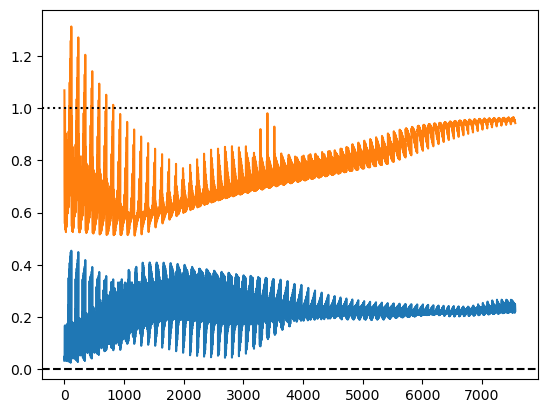

In [8]:
normalized_stellar_models = (stellar_models.T/jnp.median(stellar_models,axis=1)).T * 0.5 # this 0.5 is to make the max more like 1 instead of 2

plt.plot(normalized_stellar_models.min(axis=1))
plt.plot(normalized_stellar_models.max(axis=1))
plt.axhline(0, c='k', linestyle='--')
plt.axhline(1, c='k', linestyle=':')

For stellar parameters, we know the range so we just remap this to 0-1.

In [9]:
spmx = jnp.max(stellar_parameter_arrs, axis=0)
spmi = jnp.min(stellar_parameter_arrs, axis=0)
sprng = spmx - spmi

def rescale_stellar_parameters(sparr):
    """
    sparr is expected to have trailing dimension matching the number of stellar parameters (3 in this case)
    """
    return (sparr - spmi) / sprng

def unscale_stellar_parameters(sparr_scaled):
    """
    sparr_scaled is expected to have trailing dimension matching the number of stellar parameters (3 in this case)
    """
    return sparr_scaled * sprng + spmi

stellar_parameters_rescaled = rescale_stellar_parameters(stellar_parameter_arrs)


It might already be there but just in case put these into the device

In [10]:
normalized_stellar_models = jax.device_put(normalized_stellar_models).block_until_ready()
stellar_parameters_rescaled = jax.device_put(stellar_parameters_rescaled).block_until_ready()

# Build and Train test MLP

In [12]:
@eqx.filter_jit
def mse_loss(model, xsp, y):
    pred_y = jax.vmap(model)(xsp)
    return jnp.mean((pred_y - y)**2) # MSE loss

@eqx.filter_jit
def make_step(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mse_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

Each batch is a fixed number of spectra, each epoch is once through the dataset

  0%|          | 0/35700 [00:00<?, ?it/s]

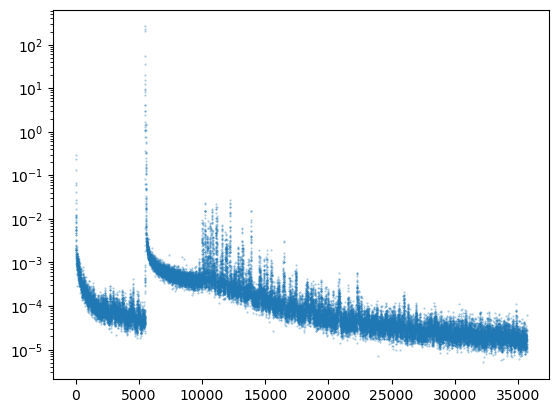

In [ ]:
BATCH_SIZE = 64
NEPOCHS = 300
LEARNING_RATE = 5e-4

nperepoch = int(np.ceil(normalized_stellar_models.shape[0] / BATCH_SIZE))

rkmod, rkepoch = jax.random.split(jax.random.key(42), 2)  # ensures reproducibility below
model = eqx.nn.MLP(3, normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.adamw(LEARNING_RATE)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

t = tqdm(total=NEPOCHS*nperepoch)

epoch_boundaries = []
losses = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = normalized_stellar_models[speci]
        sparams = stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}')
        losses.append(loss_value)

    epoch_boundaries.append(len(losses))
t.refresh()

plt.semilogy(losses,'.', ms=1, alpha=.4)

In [78]:
jax.random.choice(jax.random.key(42), stellar_parameters_rescaled.shape[0], (axs.size-1,))

Array([2655, 3533, 1915, 3893, 1172], dtype=int32)

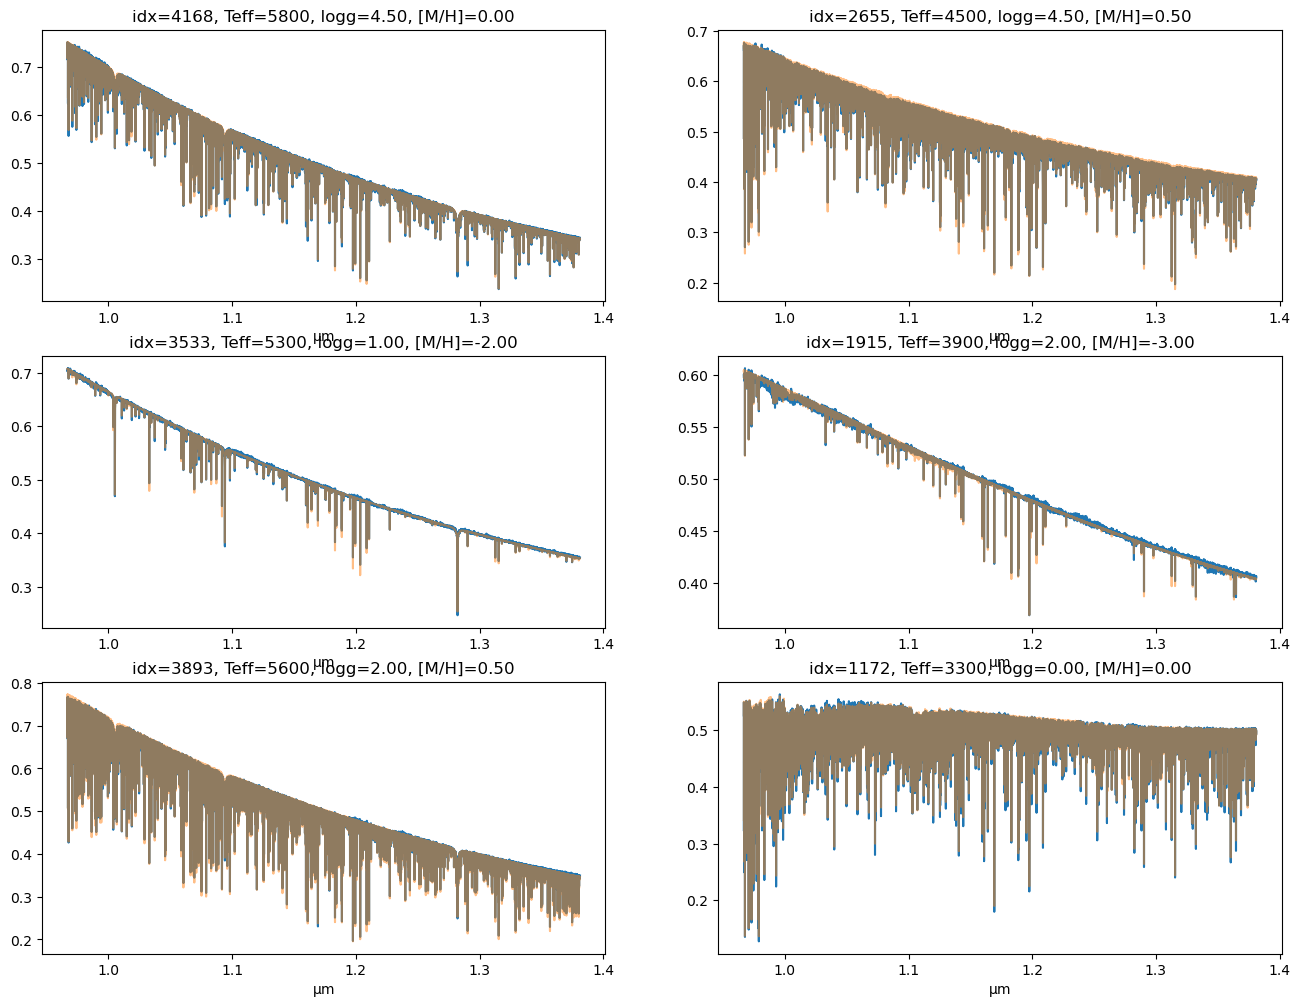

In [80]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), stellar_parameters_rescaled.shape[0], (axs.size-1,))
idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(stellar_parameters_rescaled[idx])[2]:.2f}")

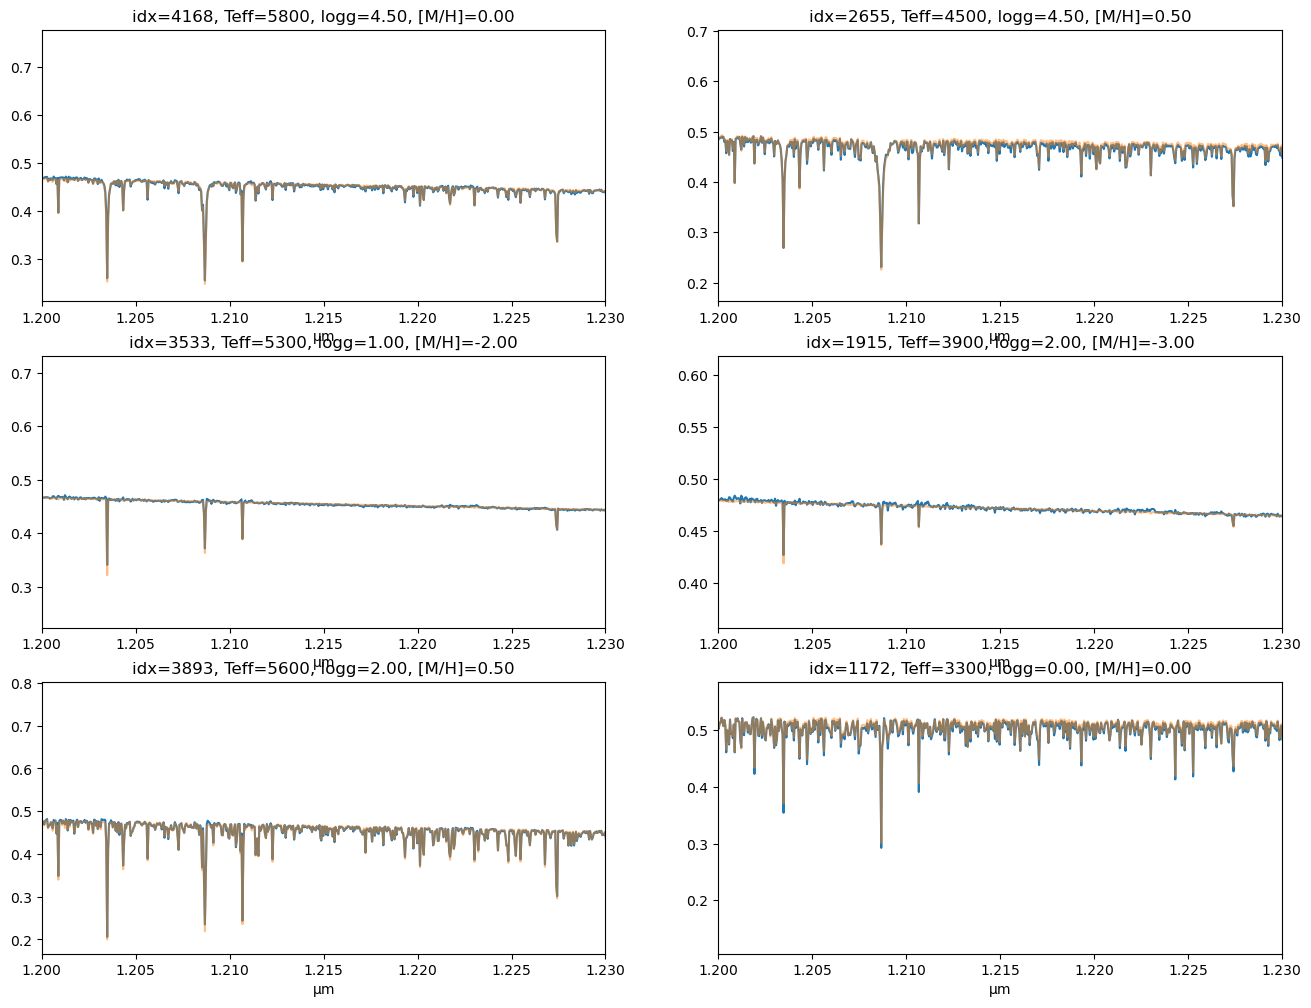

In [82]:
for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

fig

In [60]:
jitted = jax.jit(model.__call__)
%time jitted(stellar_parameters_rescaled[sunlike_idx]).block_until_ready()
%timeit jitted(stellar_parameters_rescaled[sunlike_idx]).block_until_ready()

CPU times: user 642 ms, sys: 246 ms, total: 888 ms
Wall time: 945 ms
592 μs ± 10.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Looks like that'll do it.  Experiment with a few different variations of training and architecture now.

# INR-inspired activations

  0%|          | 0/35700 [00:00<?, ?it/s]

E0828 14:06:06.890585  118049 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.15 = f32[64,2048]{1,0} fusion(sub.3, dynamic_nodonate__first___6_.1), kind=kCustom, calls=gemm_fusion_dot_general.15_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["32","16"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0828 14:06:06.891203  118049 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.15_computation.clone {
  parameter_0.4 = f32[64,8945]{1,0} parameter(0)
  constant_5 = f32[] constant(3.49357174e-06)
  broadcast.8 = f32[64,8945]{1,0} broadcast(constant_5), dimensions={}
  broadcast_in_dim.0 = f32[64,8945]{1,0} multiply(parameter_0.4, broadcast.8)
  parameter_1.4 = f32[8

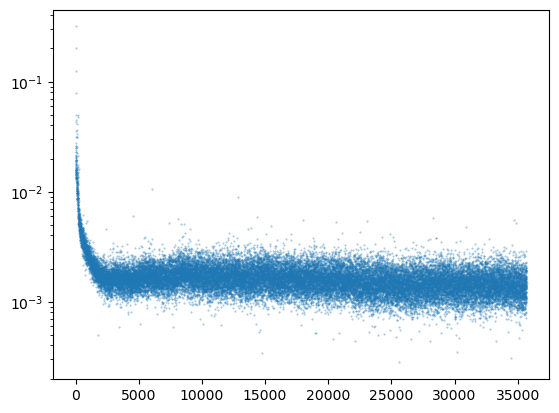

In [13]:
BATCH_SIZE = 64
NEPOCHS = 300
LEARNING_RATE = 5e-4

nperepoch = int(np.ceil(normalized_stellar_models.shape[0] / BATCH_SIZE))

rkmod, rkepoch = jax.random.split(jax.random.key(42), 2)  # ensures reproducibility below

def gabor_real_nonlinearity(x1, w0=10, s0=20):
    return jnp.cos(w0 * x1) * jnp.exp(-(x1 * s0)**2)
model = eqx.nn.MLP(3, normalized_stellar_models.shape[1], 2048, 3, activation=gabor_real_nonlinearity, key=rkmod)

optim = optax.adamw(LEARNING_RATE)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

t = tqdm(total=NEPOCHS*nperepoch)

epoch_boundaries = []
losses = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = normalized_stellar_models[speci]
        sparams = stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}')
        losses.append(loss_value)

    epoch_boundaries.append(len(losses))
t.refresh()

plt.semilogy(losses,'.', ms=1, alpha=.4)

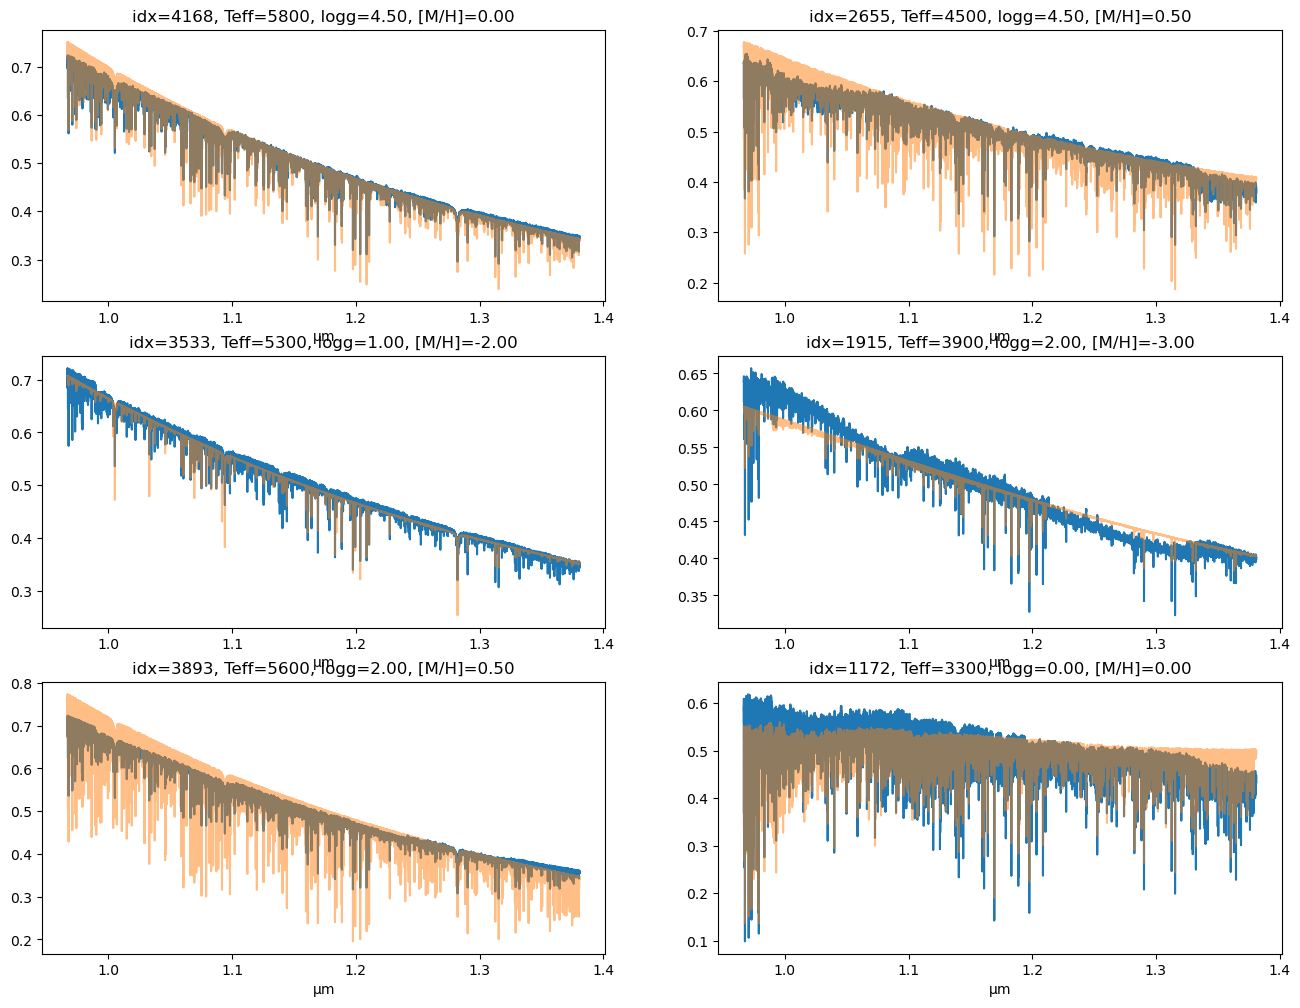

In [14]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), stellar_parameters_rescaled.shape[0], (axs.size-1,))
idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(stellar_parameters_rescaled[idx])[2]:.2f}")

Doesn't seem notably better than vanilla mlps

# Better training

Use a validation hold-out group and a lr schedule

  0%|          | 0/242500 [00:00<?, ?it/s]

E0831 14:36:54.153609  575563 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[1511,2048]{1,0} fusion(mul.15, dynamic_nodonate__first___2_.1), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0831 14:36:54.153683  575563 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0.1 = f32[1511,2048]{1,0} parameter(0)
  parameter_1.1 = f32[2048,2048]{1,0} parameter(1)
  ROOT dot.5 = f32[1511,2048]{1,0} dot(parameter_0.1, parameter_1.1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0831 14:36:55.090770  575576 c

Text(0, 0.5, 'LR')

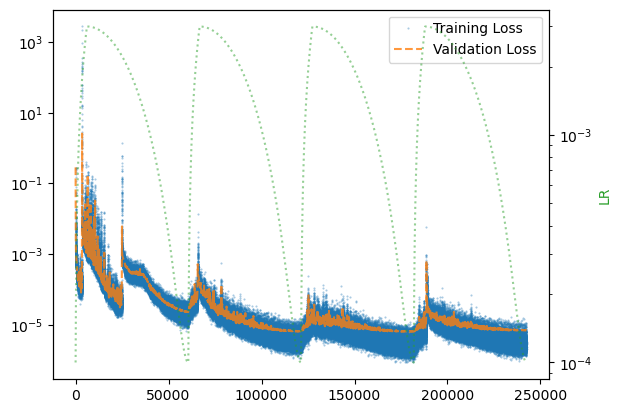

In [12]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mse_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

    vlosses.append(mse_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

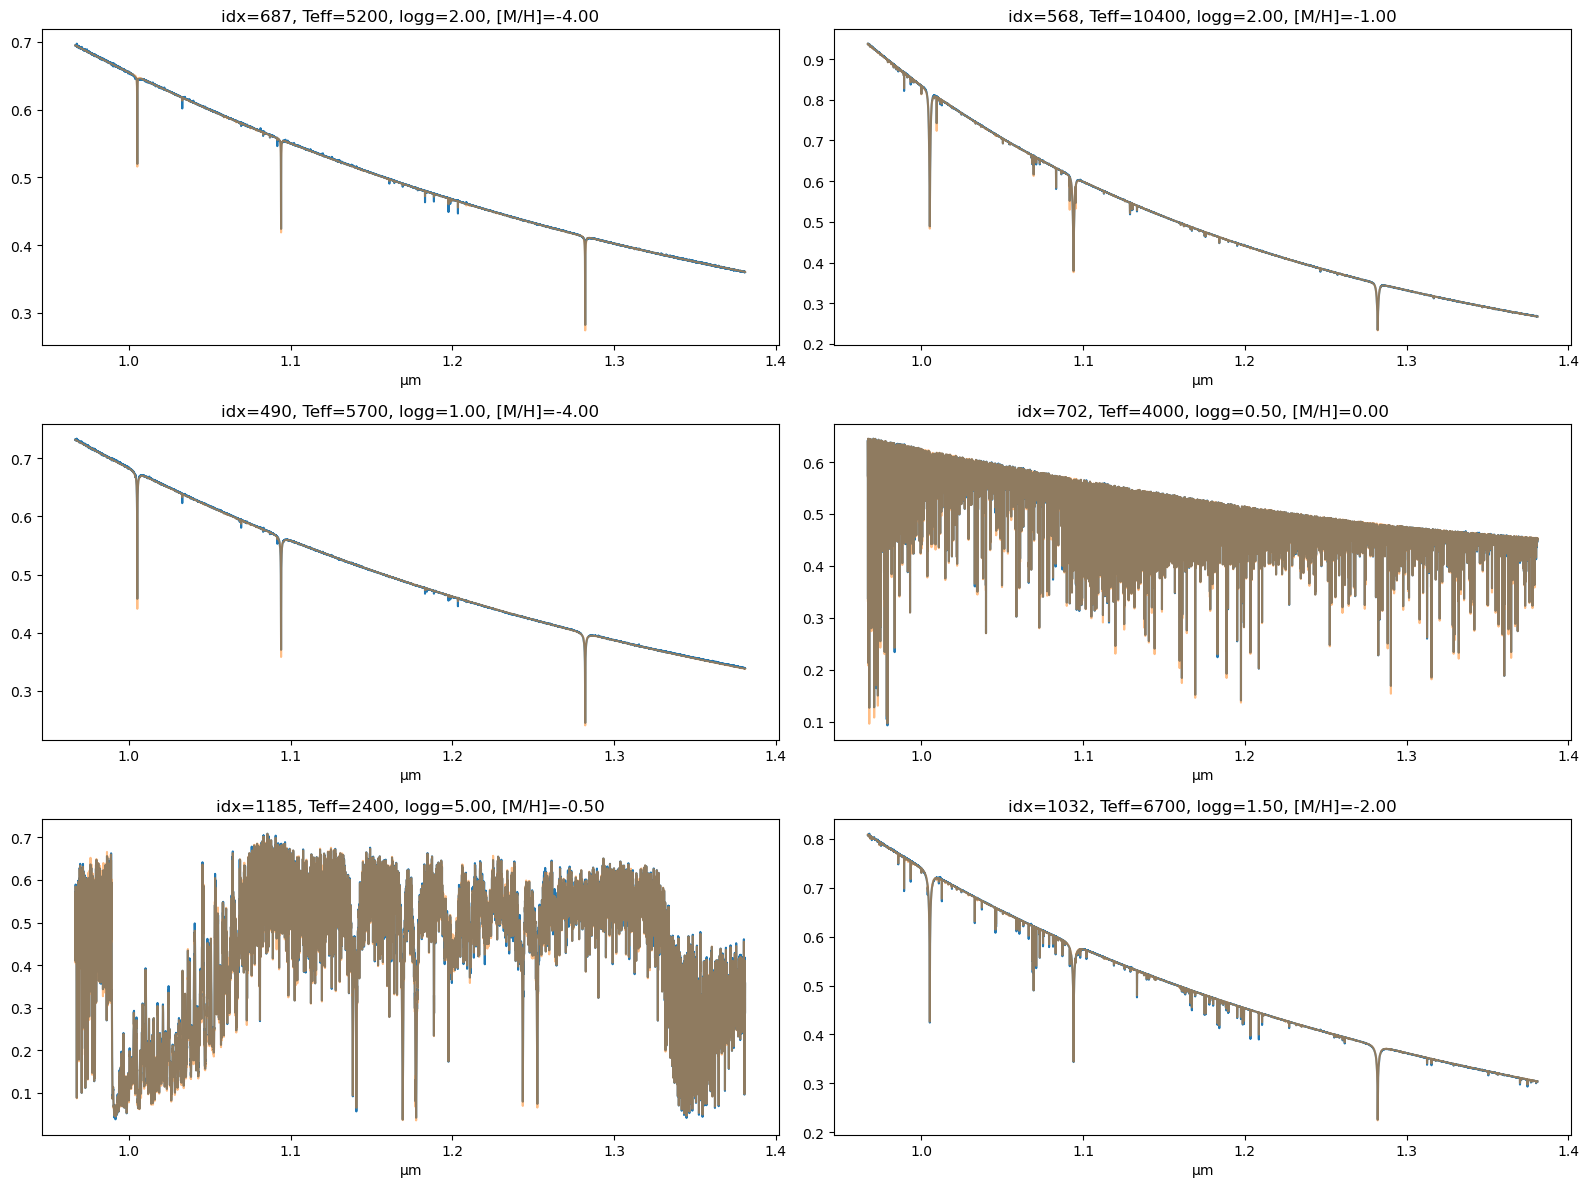

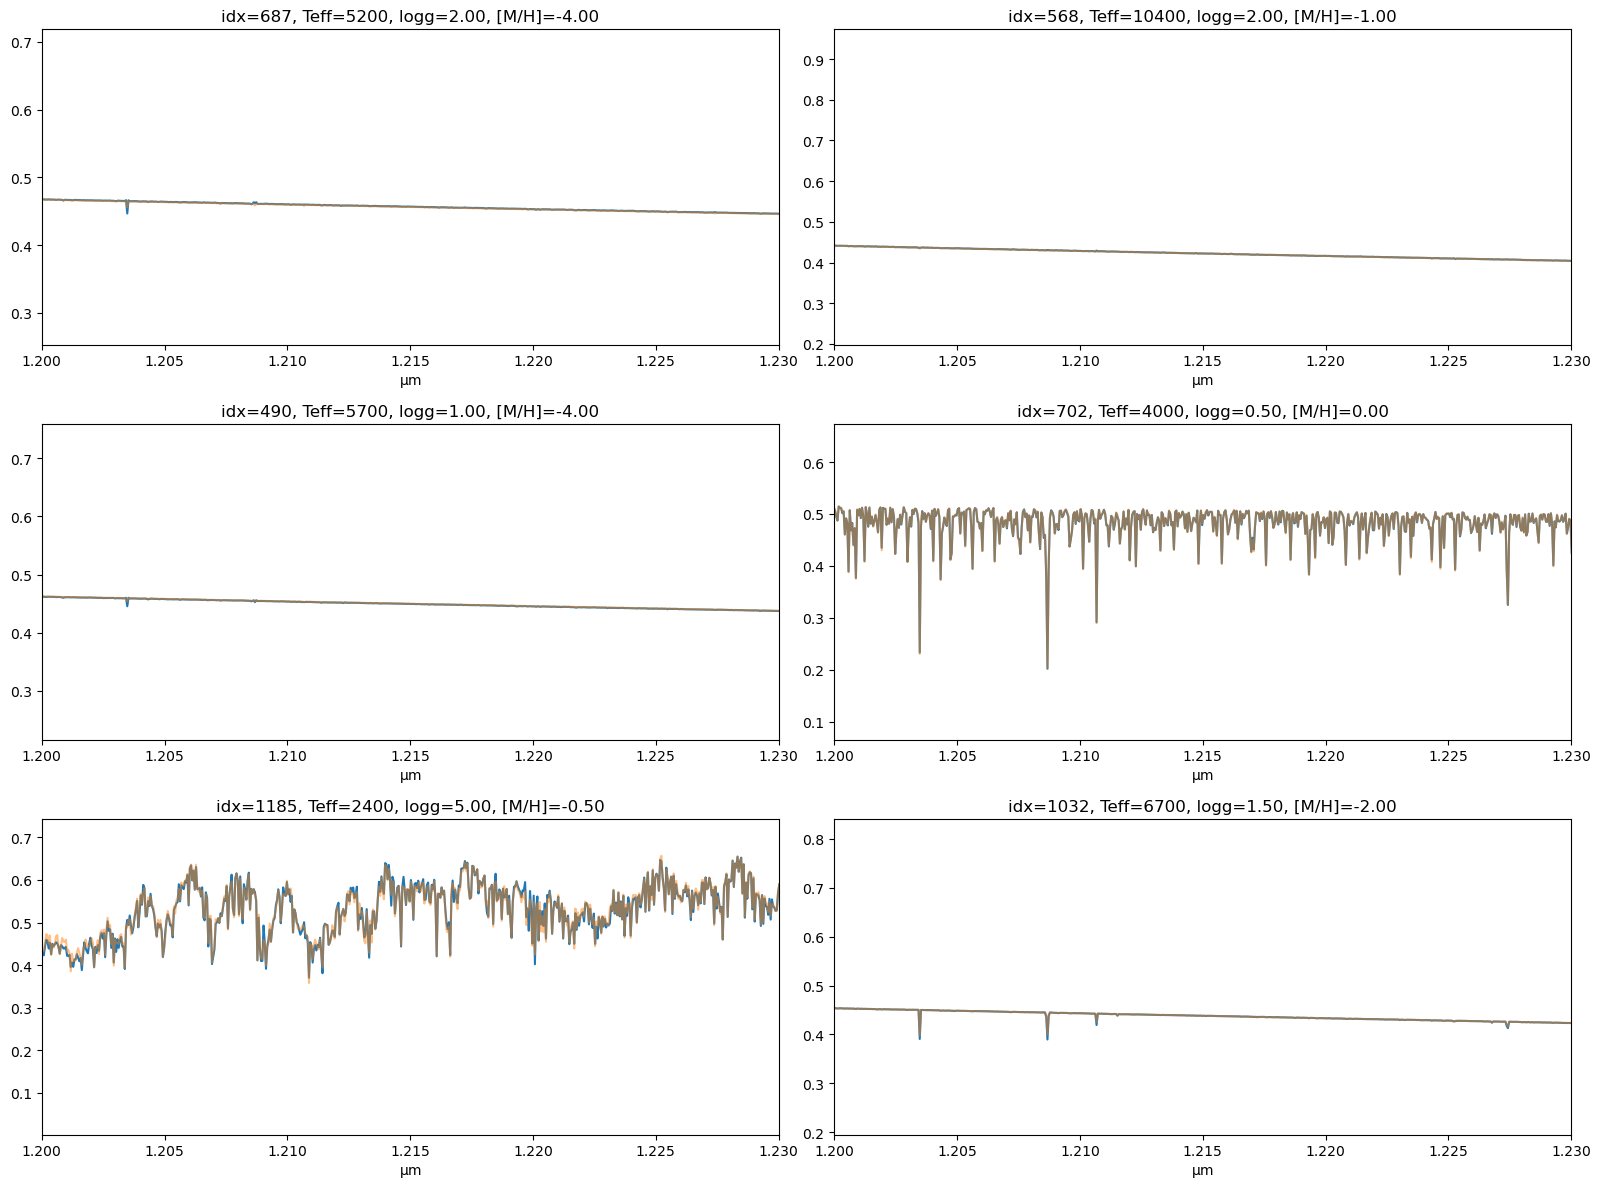

In [23]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

# Other losses

In [12]:
@eqx.filter_jit
def mean_huber_loss(model, xsp, y, delta=1.0):
    pred_y = jax.vmap(model)(xsp)
    # the factor of 2 is to make the loss more directly comparable to MSE loss in magnitude
    return 2*jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))  

@eqx.filter_jit
def make_step_huber(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mean_huber_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

Text(0, 0.5, 'LR')

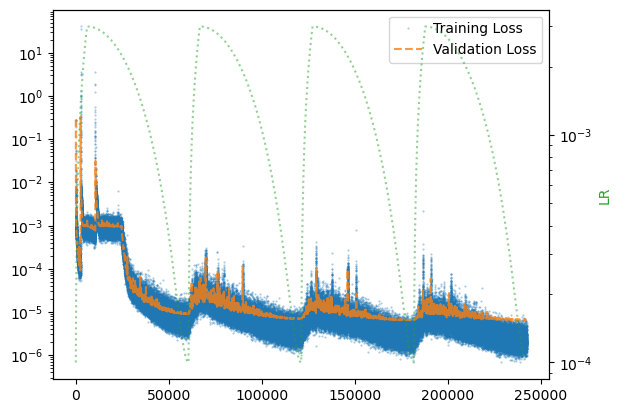

In [19]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mse_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step_huber(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

    vlosses.append(mean_huber_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

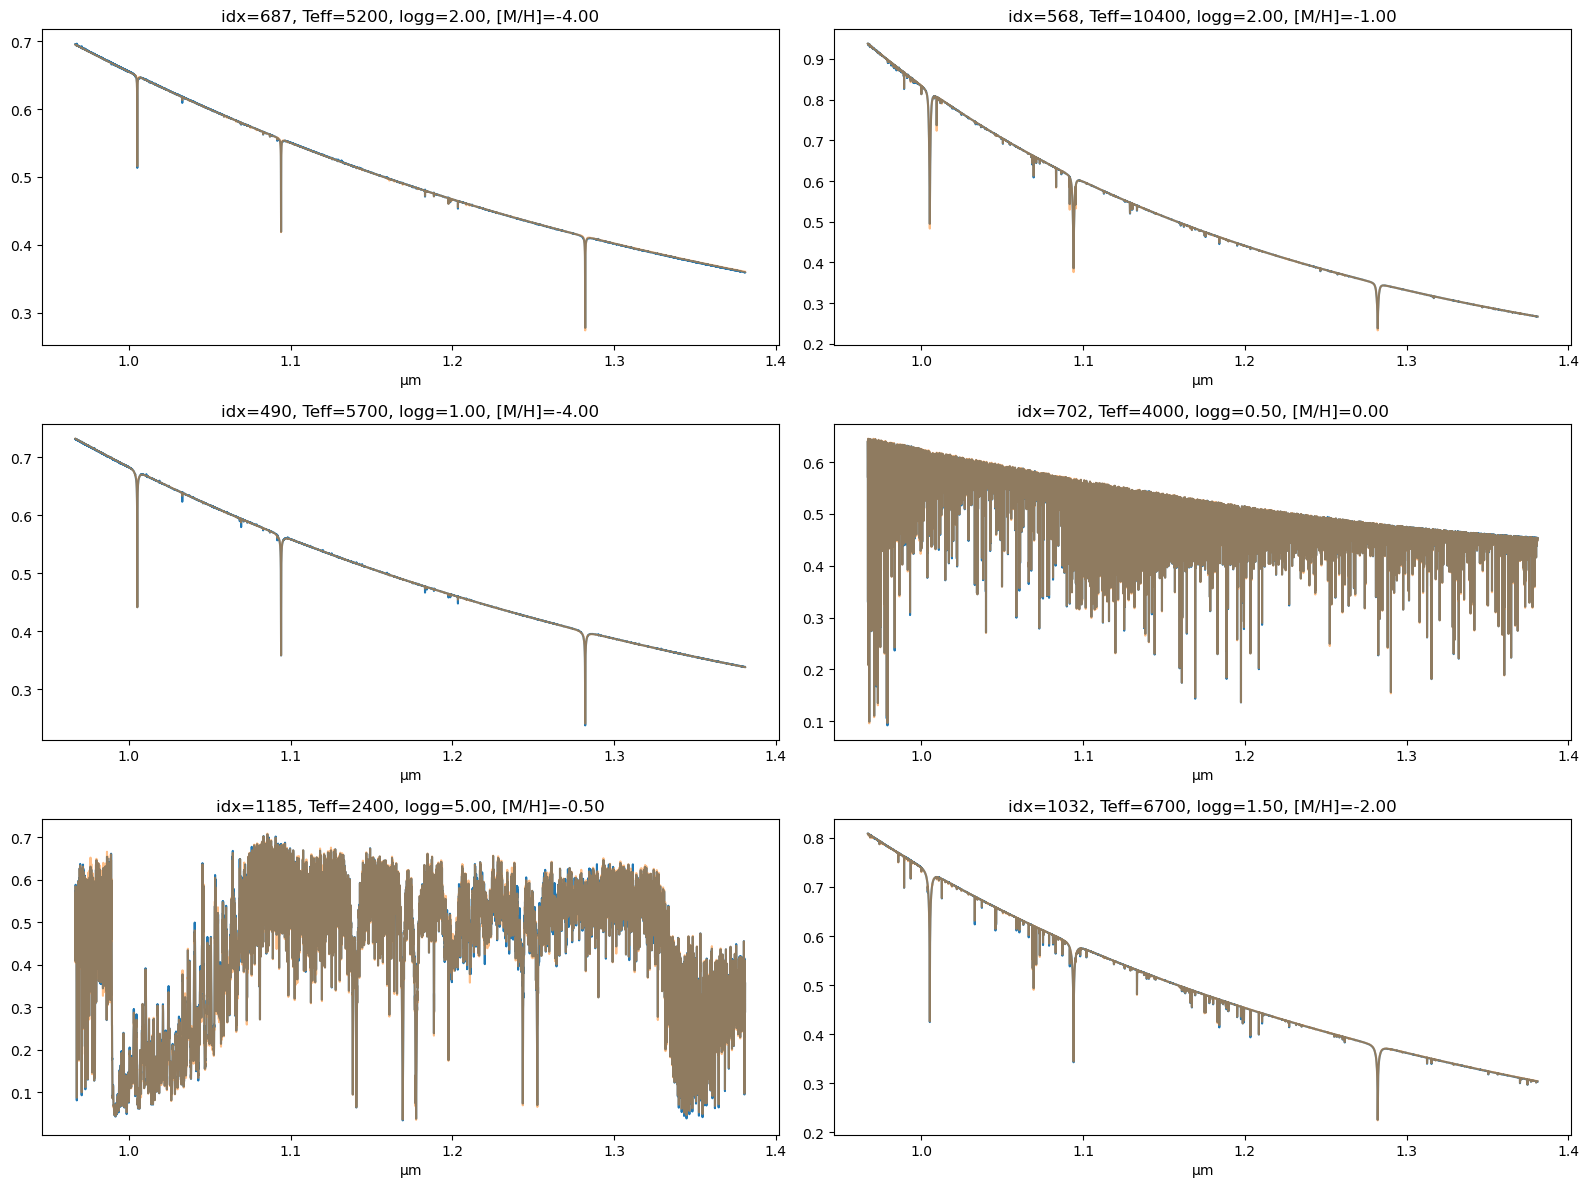

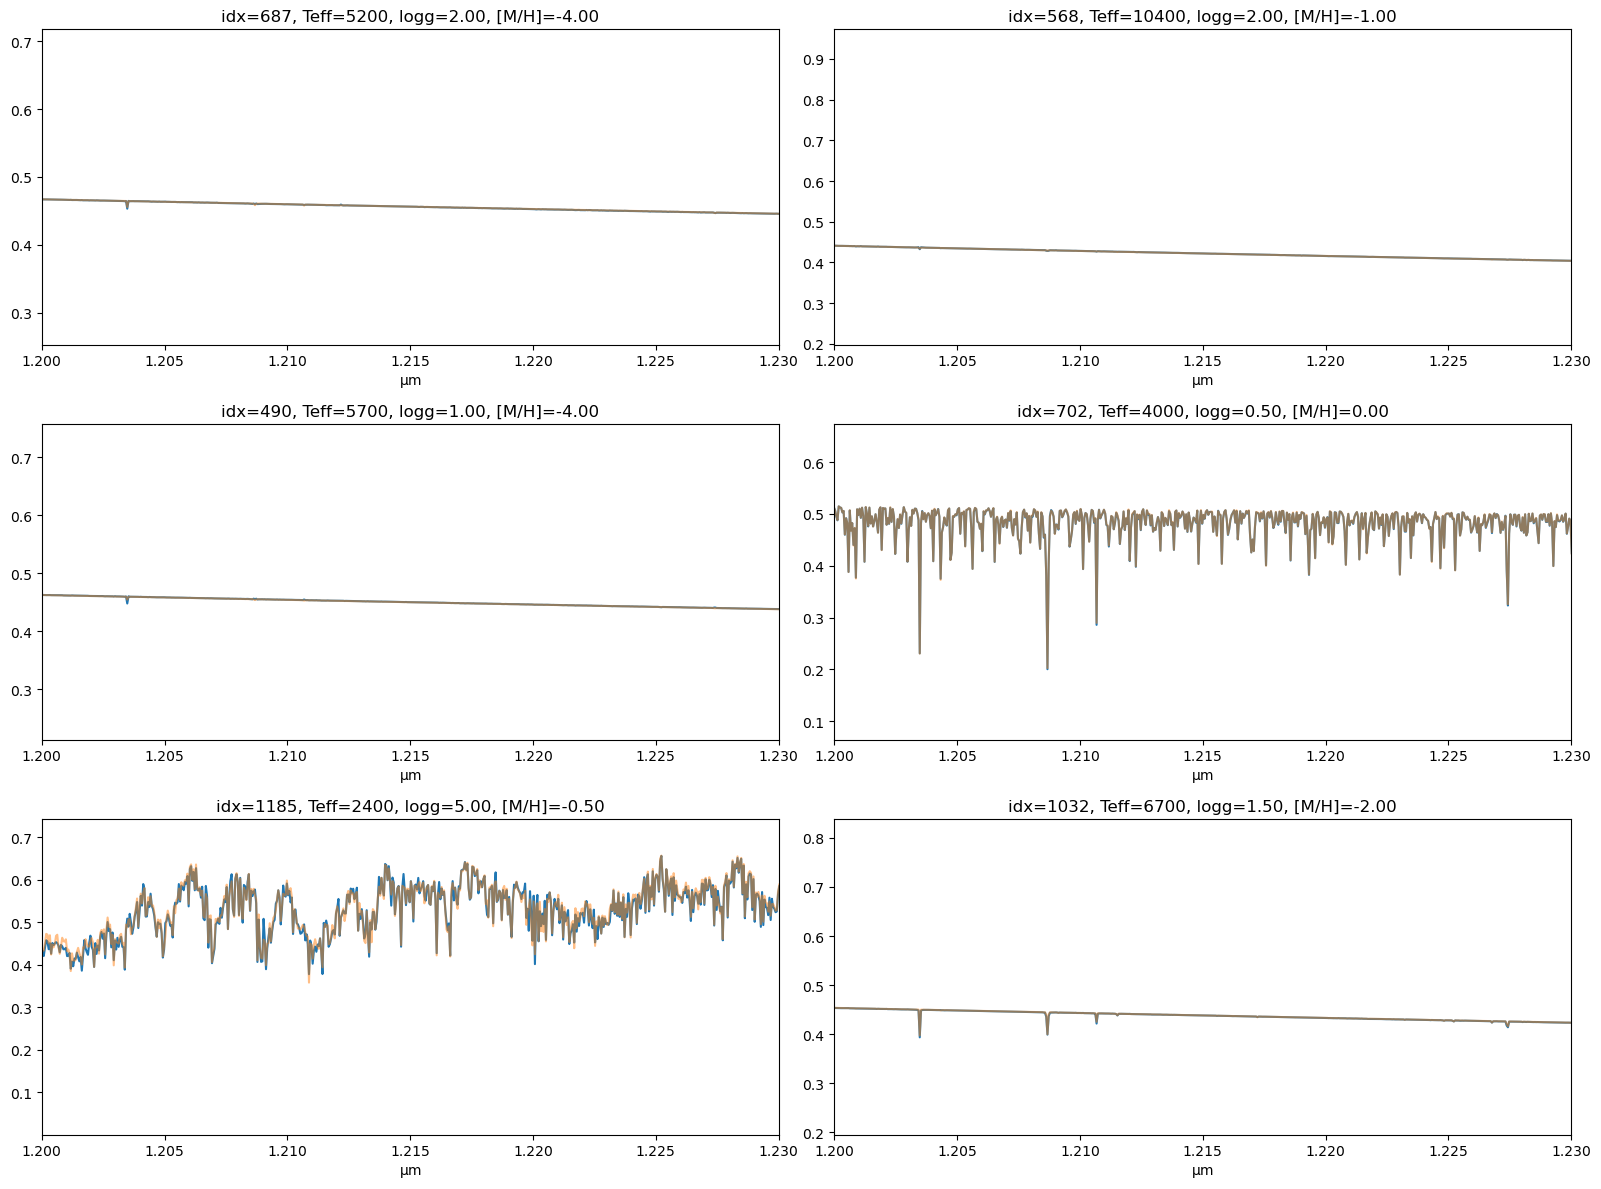

In [20]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

In [21]:
@eqx.filter_jit
def mean_logcosh_loss(model, xsp, y):
    pred_y = jax.vmap(model)(xsp)
    # the factor of 2 is to make the loss more directly comparable to MSE loss in magnitude
    return 2*jnp.mean(optax.losses.log_cosh(pred_y, y))  

@eqx.filter_jit
def make_step_logcosh(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mean_logcosh_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

Text(0, 0.5, 'LR')

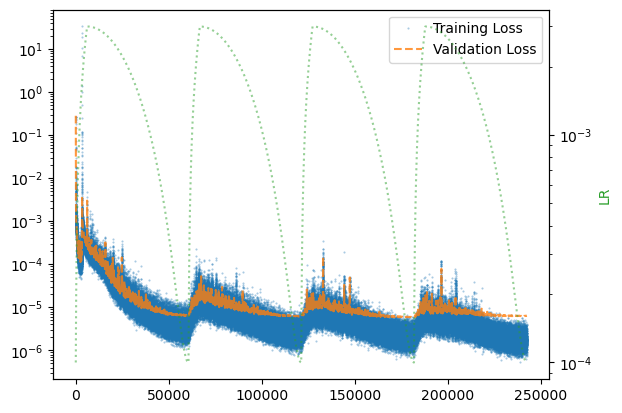

In [22]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mse_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step_logcosh(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

    vlosses.append(mean_logcosh_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

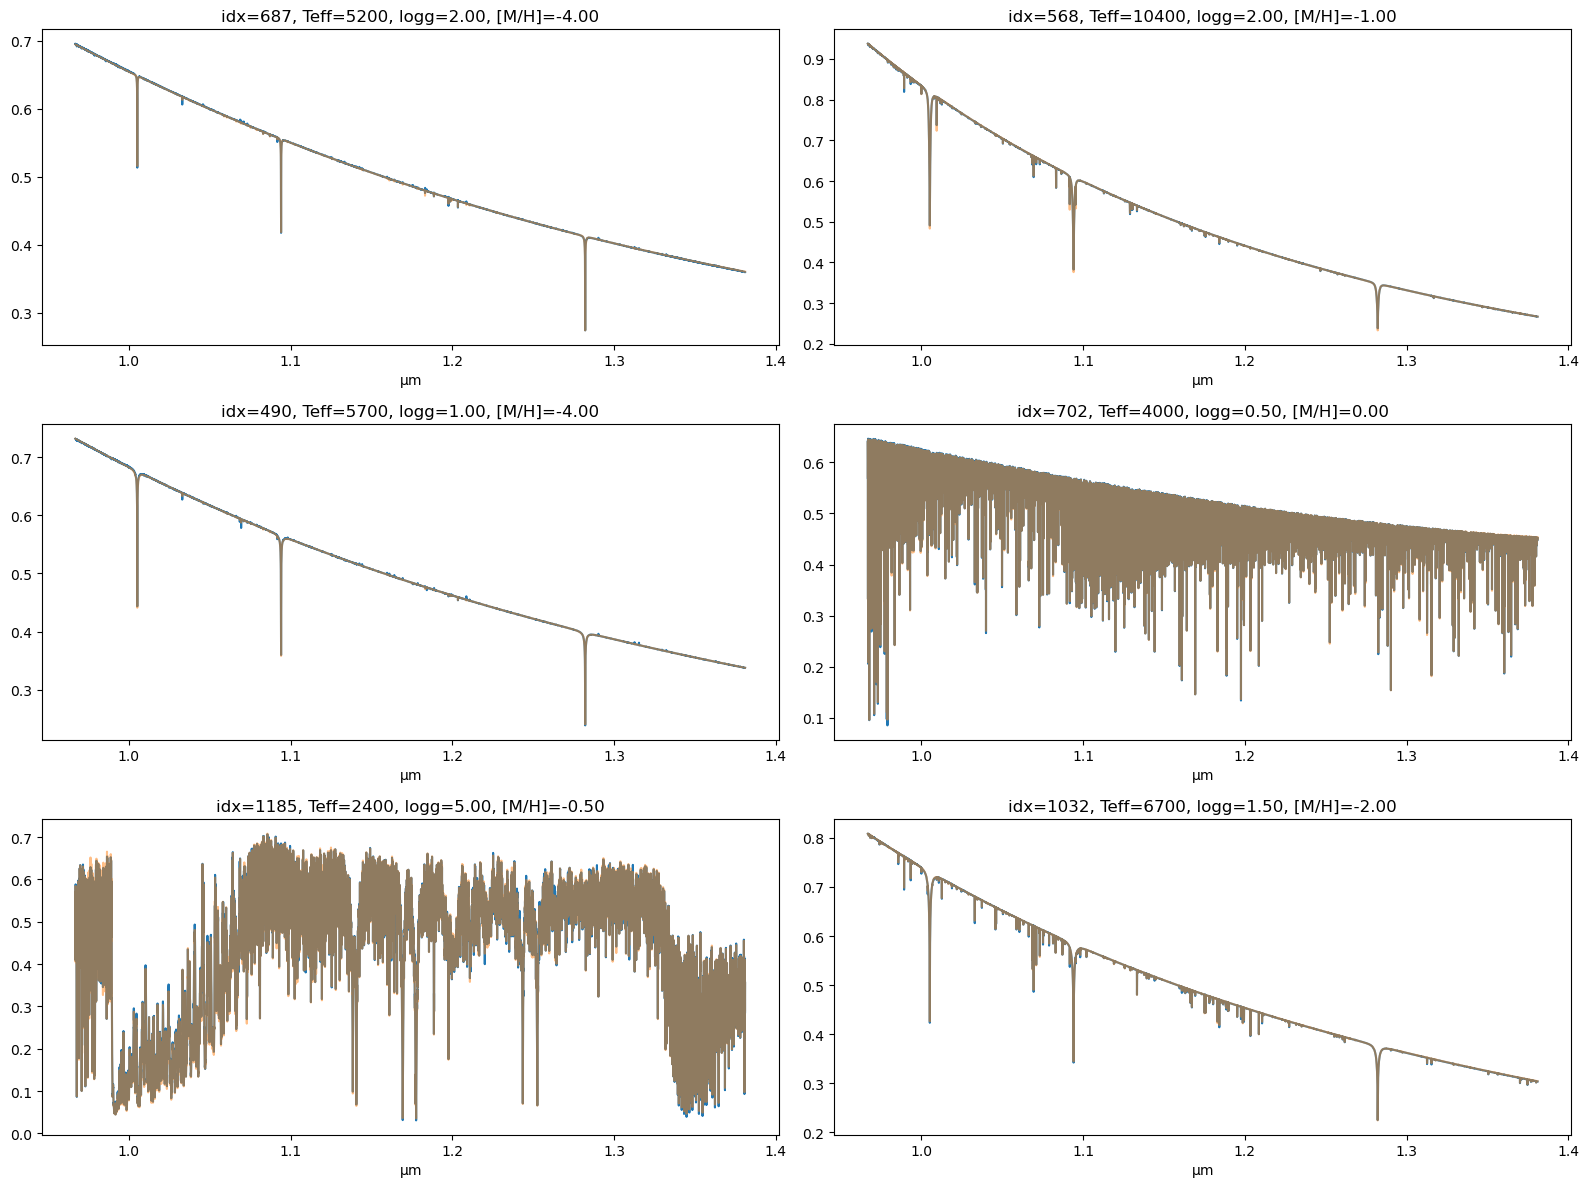

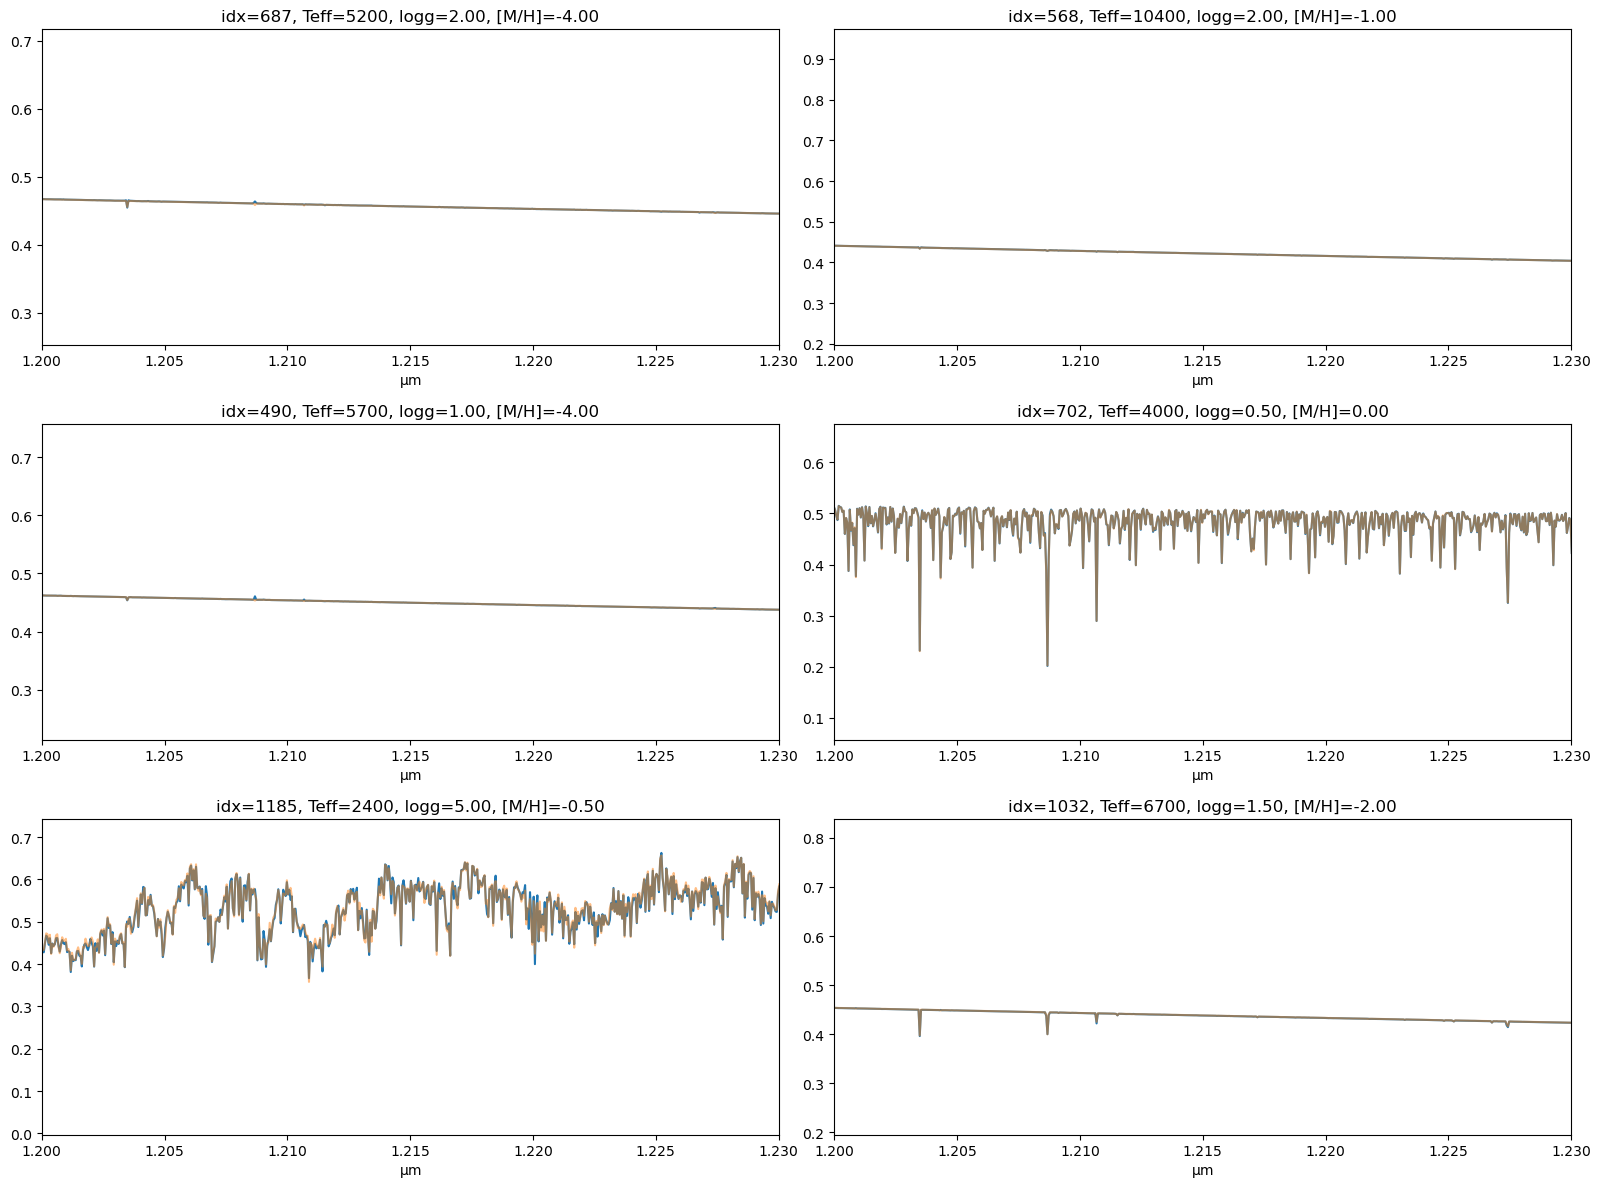

In [23]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

Log-cosh is a bit slower but seems to have similar performance.  All seem to over-fit after the first cycle. Try just doing a single cycle

  0%|          | 0/242500 [00:00<?, ?it/s]

E0901 12:57:40.938117    7350 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.8 = f32[2,64,2048]{2,1,0} fusion(add_any.2, dynamic_nodonate__first___6_.1), kind=kCustom, calls=gemm_fusion_dot_general.8_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","32"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0901 12:57:40.941302    7350 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.8_computation.clone {
  parameter_0.4 = f32[64,8945]{1,0} parameter(0)
  constant = f32[] constant(0)
  pad = f32[64,8952]{1,0} pad(parameter_0.4, constant), padding=0_0x0_7
  bitcast = f32[64,2,4476]{2,1,0} bitcast(pad)
  parameter_1.4 = f32[8945,2048]{1,0} parameter(1)
  const

Text(0, 0.5, 'LR')

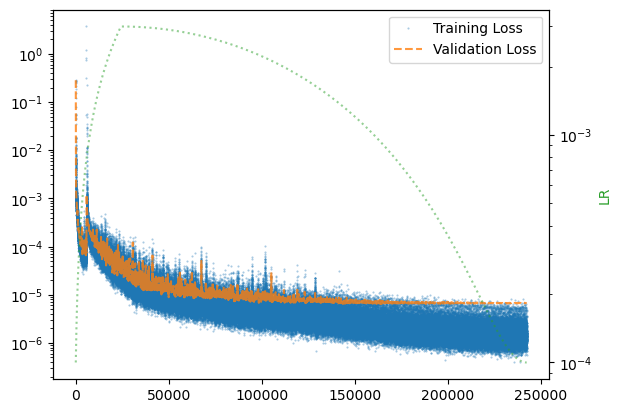

In [13]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 1
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mse_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step_huber(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

    vlosses.append(mean_huber_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

Definitely over-fitting.  Try adding dropout

# Add dropout

In [42]:
class DropoutMLP(eqx.Module):
    layers: list

    def __init__(self, in_size, out_size, width_size, depth, rkey, dropout_rate=0.1, activation=jax.nn.gelu, firstdropout=True, lastdropout=True):
        keys = jax.random.split(rkey, depth+1)
        self.layers = [eqx.nn.Linear(in_size, width_size, key=keys[0]), eqx.nn.Lambda(activation)]
        if firstdropout:
            self.layers.append(eqx.nn.Dropout(dropout_rate))
        for i in range(1, depth-1):
            self.layers.append(eqx.nn.Linear(width_size, width_size, key=keys[i+1]))
            self.layers.append(eqx.nn.Lambda(activation))
            self.layers.append(eqx.nn.Dropout(dropout_rate))
        if not lastdropout:
            del self.layers[-1]
        self.layers.append(eqx.nn.Linear(width_size, out_size, key=keys[-1]))


    def __call__(self, x, rkey):
        for layer in self.layers:
            thiskey, rkey = jax.random.split(rkey)
            x = layer(x, key=thiskey)
        return x

In [36]:
@eqx.filter_jit
def mean_huber_loss_dropout(model, xsp, y, rkey, delta=1.0):
    pred_y = jax.vmap(model, in_axes=(0, None))(xsp, rkey)
    # the factor of 2 is to make the loss more directly comparable to MSE loss in magnitude
    return 2*jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))  

@eqx.filter_jit
def make_step_dropout(model, opt_state, xsp, y, rkey):
    loss_value, grads = eqx.filter_value_and_grad(mean_huber_loss_dropout)(model, xsp, y, rkey)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

Text(0, 0.5, 'LR')

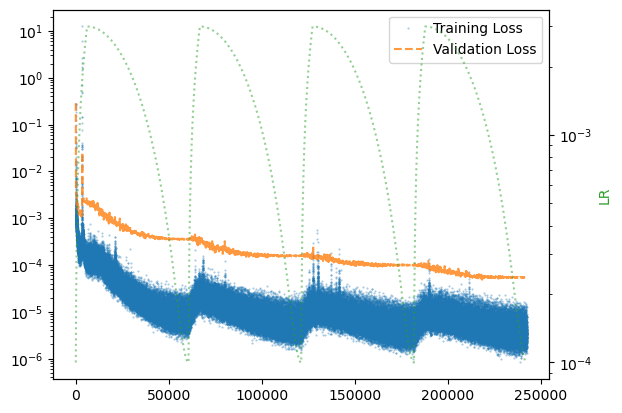

In [49]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit, rkexec = jax.random.split(jax.random.key(42), 4)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = DropoutMLP(3, train_normalized_stellar_models.shape[1], 2048, 3, dropout_rate=0.05, activation=jax.nn.gelu, rkey=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mean_huber_loss_dropout(eqx.nn.inference_mode(model), validation_stellar_parameters_rescaled, validation_normalized_stellar_models, rkexec)]
tlosses = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        rkthis, rkstep = jax.random.split(rkexec)
        model, opt_state, loss_value = make_step_dropout(model, opt_state, sparams, sflux, rkey=rkthis)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

    vlosses.append(mean_huber_loss_dropout(eqx.nn.inference_mode(model), validation_stellar_parameters_rescaled, validation_normalized_stellar_models, rkey=rkstep))
    epoch_boundaries.append(len(tlosses))
t.refresh()

model = eqx.nn.inference_mode(model)

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

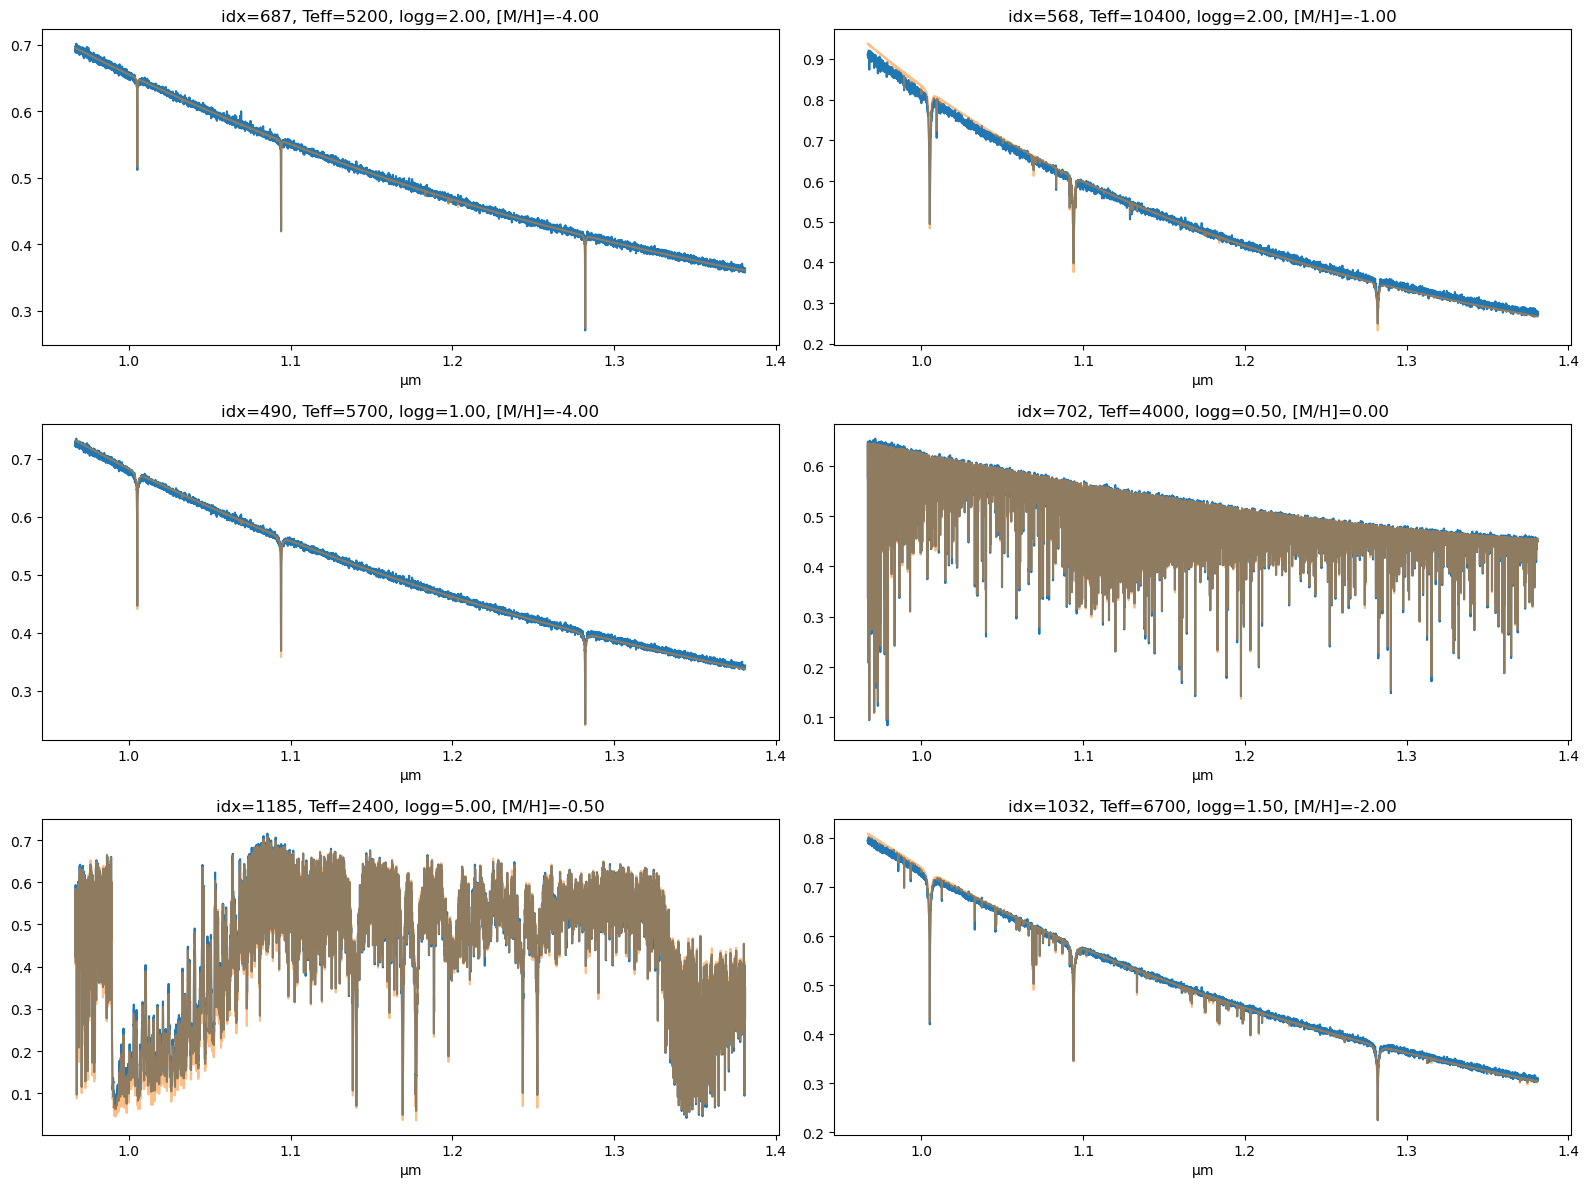

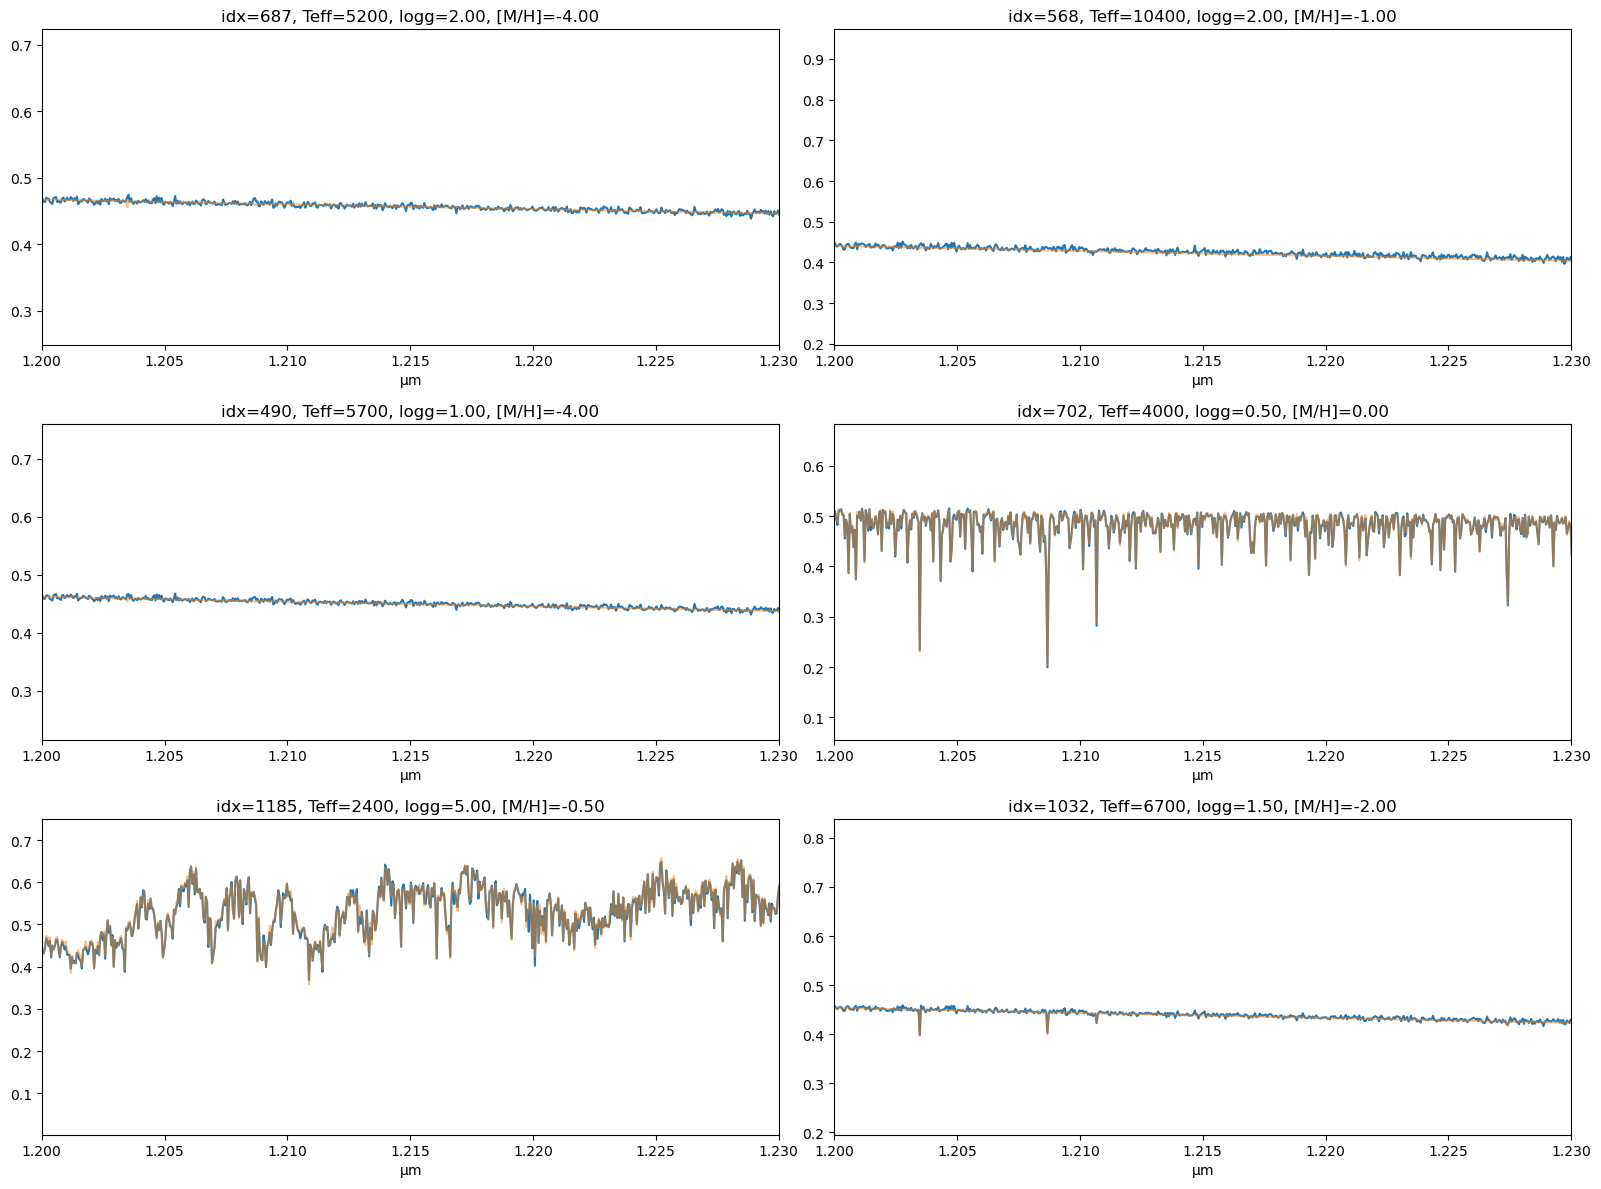

In [50]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx], rkey=rkexec)
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

How strange - dropout makes the generalization worse by getting the normalization all wrong and the noise levels...

# Gradient matching loss

In [ ]:
@eqx.filter_jit
def mean_loss(model, xsp, y, delta=1.0, lamb=0.2):
    pred_y = jax.vmap(model)(xsp)

    huber_term = 2*jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    # the factor of 2 is to make the loss more directly comparable to MSE loss
    return (1-lamb)*huber_term + lamb * grad_term

@eqx.filter_jit
def make_step(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mean_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

E0903 11:12:58.446070   28927 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.8 = f32[4,64,2048]{2,1,0} fusion(add_any.6, dynamic_nodonate__first___6_.1), kind=kCustom, calls=gemm_fusion_dot_general.8_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0903 11:12:58.446152   28927 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.8_computation.clone {
  parameter_0.4 = f32[64,8945]{1,0} parameter(0)
  constant = f32[] constant(0)
  pad = f32[64,8960]{1,0} pad(parameter_0.4, constant), padding=0_0x0_15
  bitcast = f32[64,4,2240]{2,1,0} bitcast(pad)
  parameter_1.4 = f32[8945,2048]{1,0} parameter(1)
  cons

Text(0, 0.5, 'LR')

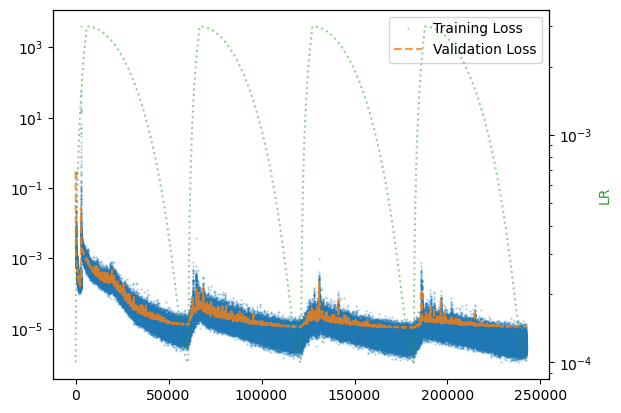

In [13]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

    vlosses.append(mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

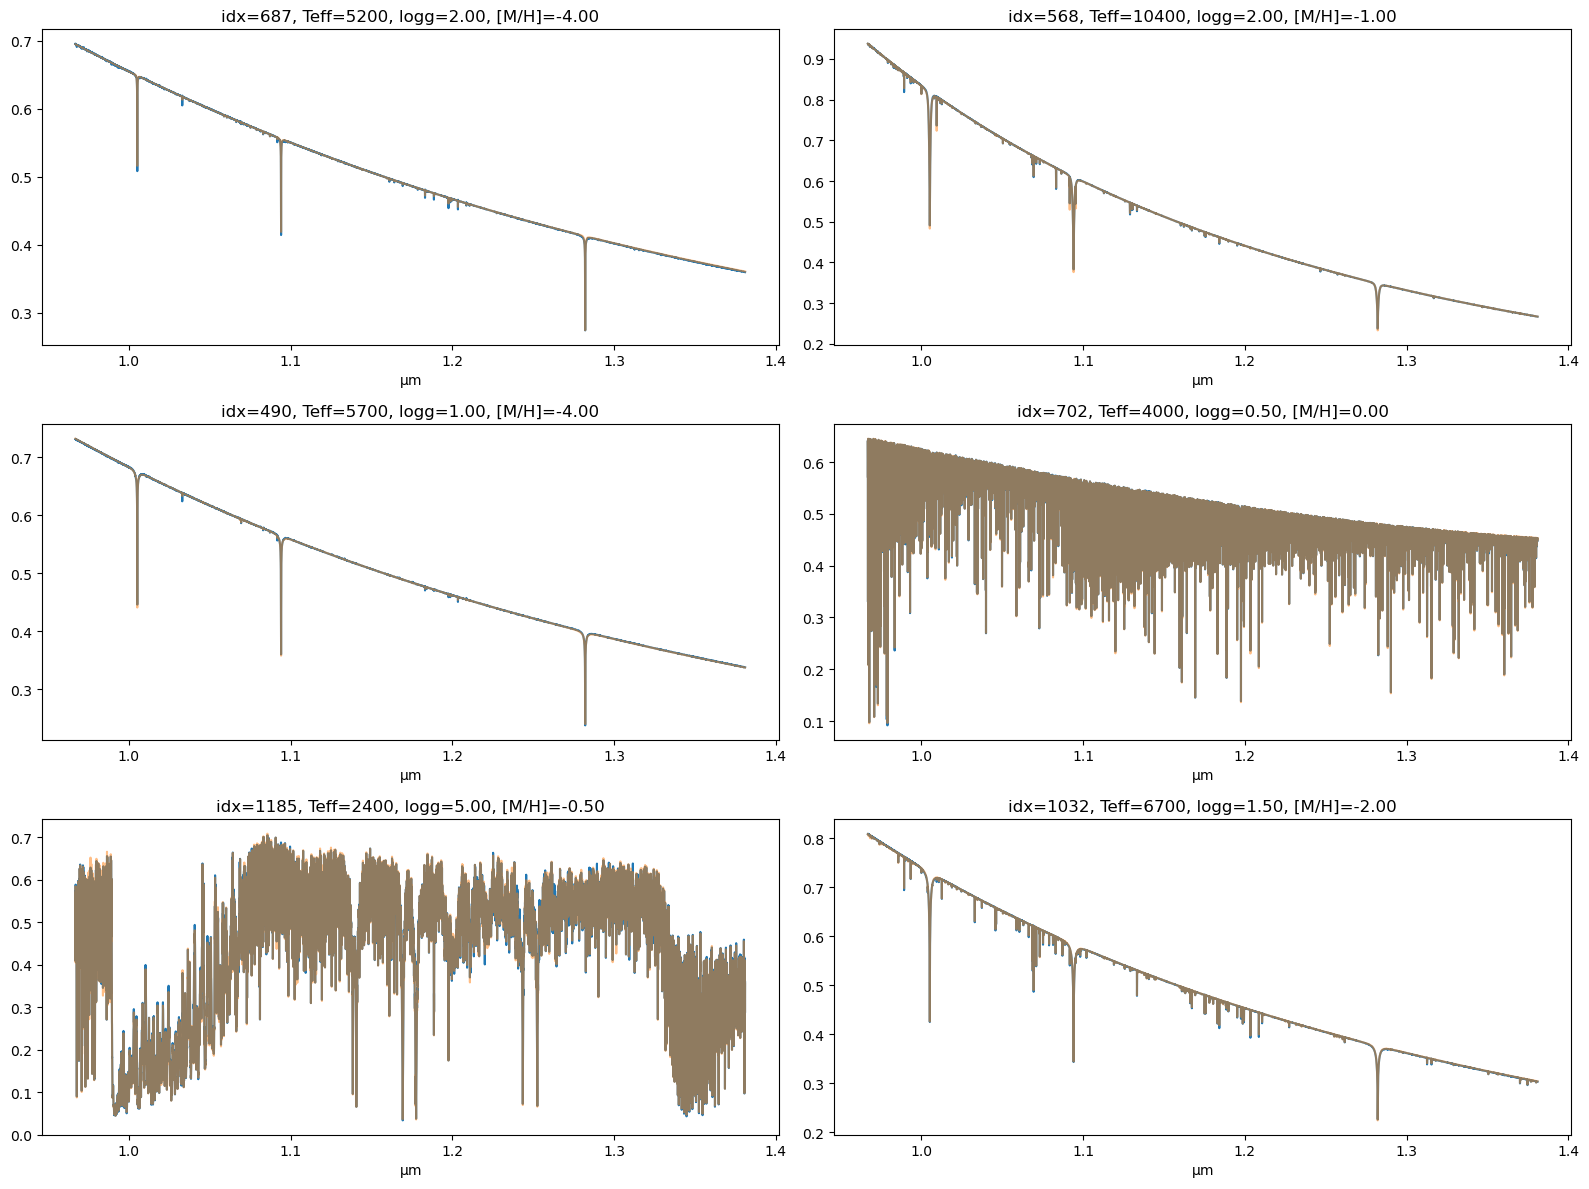

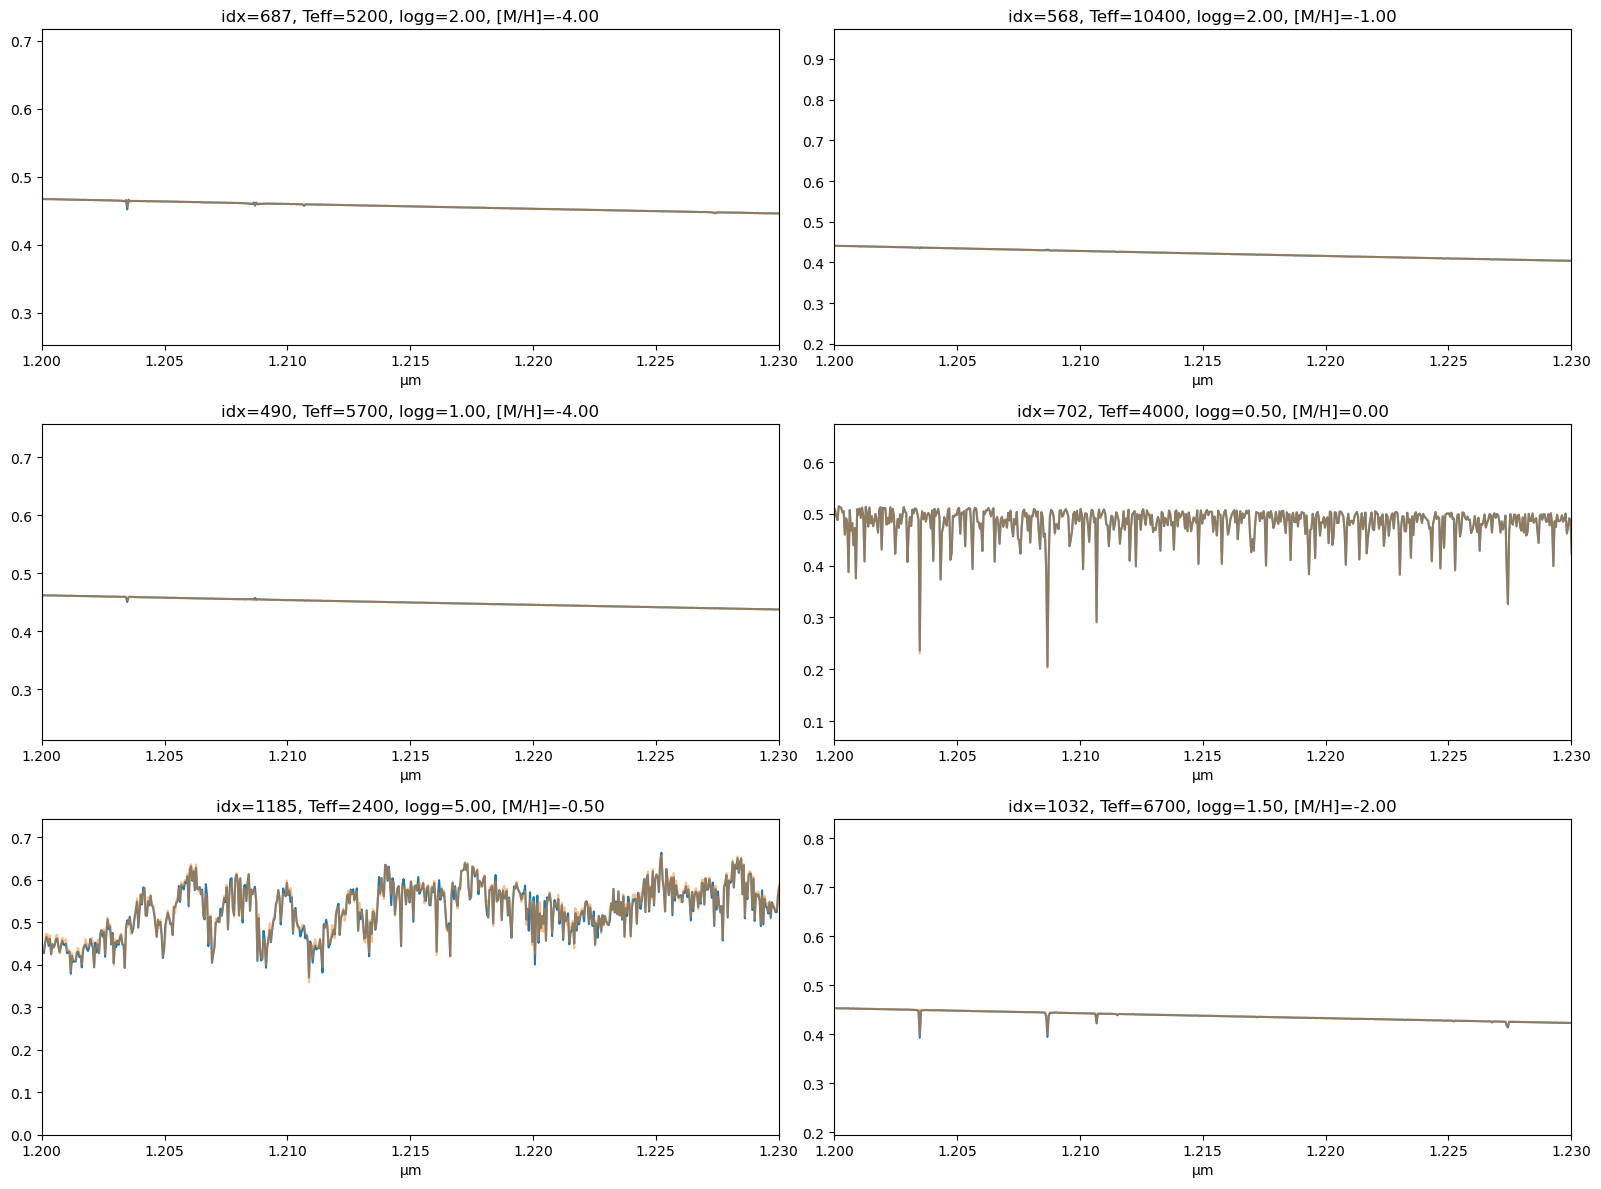

In [14]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel())
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5)
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

Surprising that didn't help with the sharp edges... use a loss that fades in the gradient?

## Gradient matching loss w/ transition

In [ ]:
@eqx.filter_jit
def mean_loss(model, xsp, y, delta=1.0, lambmax=2, lambmin=1, s=.3, lthresh=-4):
    pred_y = jax.vmap(model)(xsp)


    # the factor of 2 is to make the loss more directly comparable to MSE loss
    huber_term = 2 * jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    w = jax.nn.sigmoid((lthresh-jnp.log10(huber_term))/s)
    
    return huber_term + (w*(lambmax - lambmin) + lambmin) * grad_term

@eqx.filter_jit
def loss_pieces(model, xsp, y, delta=1.0, lambmax=2, lambmin=1., s=.3, lthresh=-4):
    pred_y = jax.vmap(model)(xsp)


    # the factor of 2 is to make the loss more directly comparable to MSE loss
    huber_term = 2 * jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    w = jax.nn.sigmoid((lthresh-jnp.log10(huber_term))/s)
    
    return huber_term, grad_term, w

@eqx.filter_jit
def make_step(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mean_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

Text(0, 0.5, 'LR')

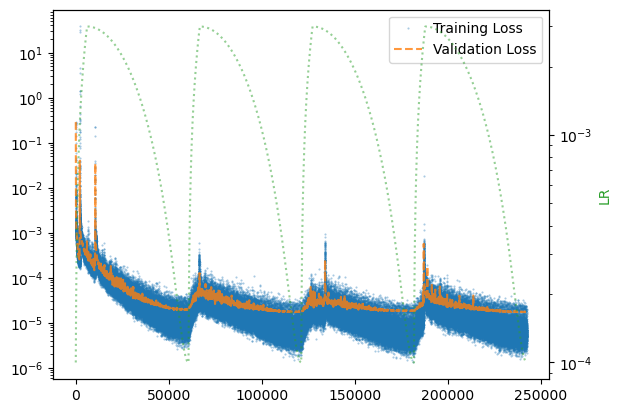

In [291]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lps = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

        lps.append(loss_pieces(model, sparams, sflux))

    vlosses.append(mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

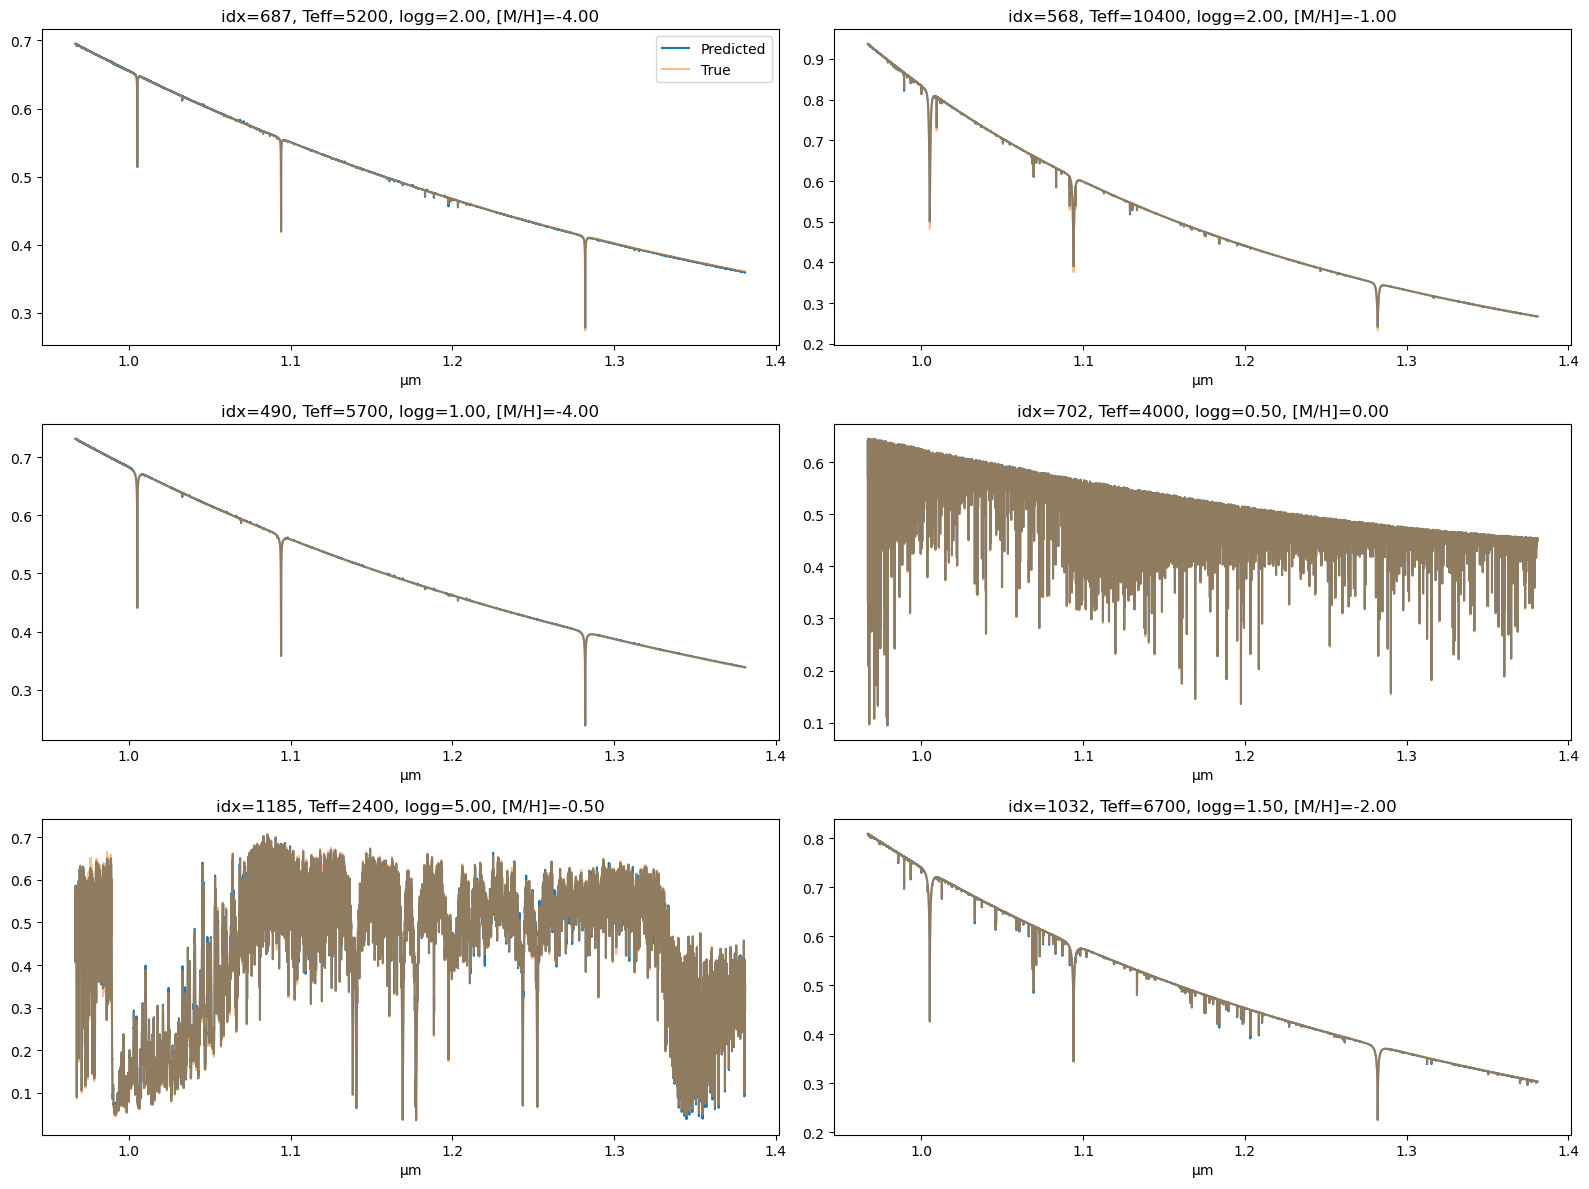

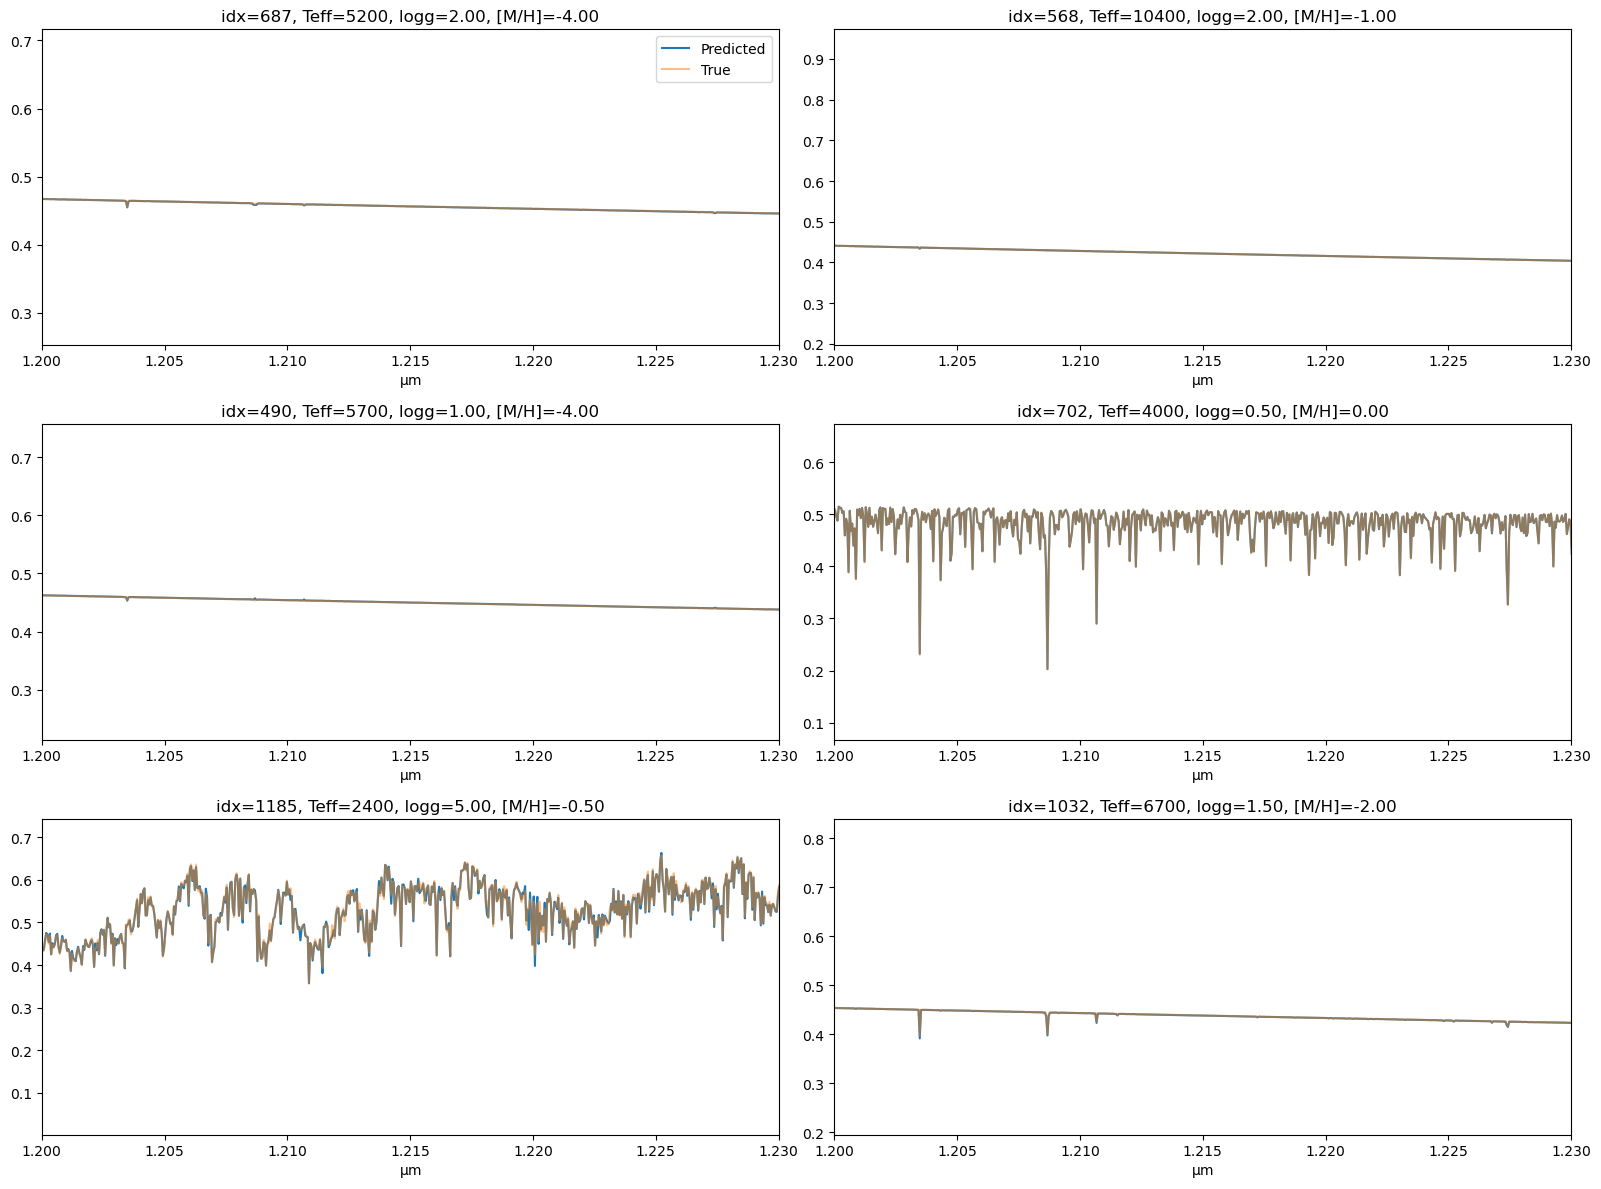

In [292]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel(), label='Predicted')
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5, label='True')
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

axs.ravel()[0].legend(loc=0)
fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

Examine the pieces of the loss separately

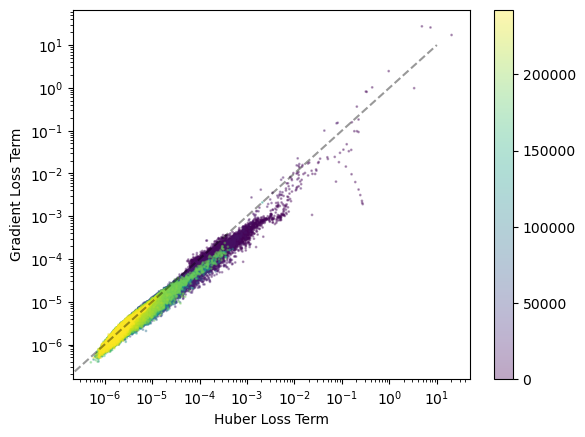

(np.float64(1.5552052788588138e-07), 0.001)

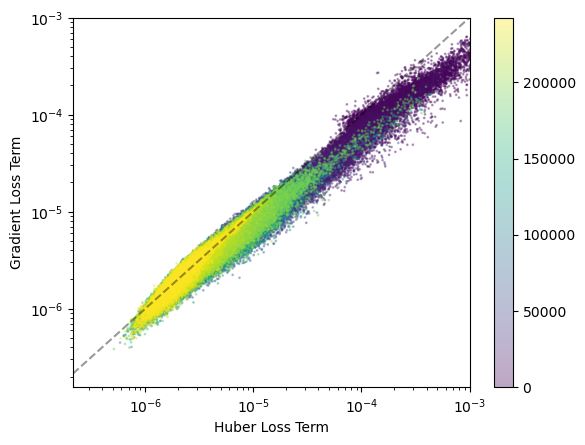

In [293]:
huber_term, grad_term, w = jnp.array(lps).T

plt.scatter(huber_term, grad_term, c=np.arange(len(huber_term)), s=1, alpha=.35)
plt.xlabel('Huber Loss Term')
plt.ylabel('Gradient Loss Term')
plt.colorbar()
plt.loglog()

plt.plot([0, 10], [0, 10], color='k', ls='--', alpha=.4)

display.display(plt.gcf())

plt.xlim(plt.xlim()[0], 1e-3)
plt.ylim(plt.ylim()[0], 1e-3)

[]

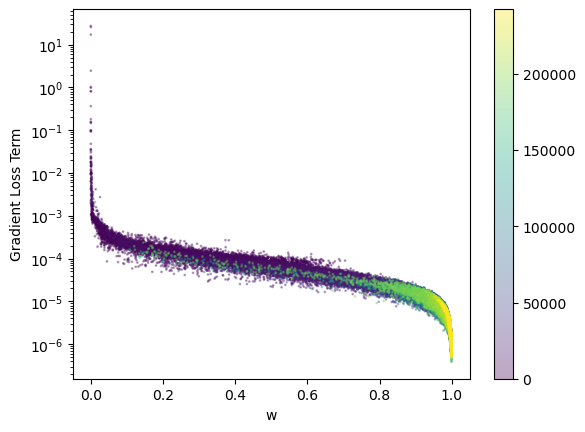

In [294]:
huber_term, grad_term, w = jnp.array(lps).T

plt.scatter(w, grad_term, c=np.arange(len(huber_term)), s=1, alpha=.35)
plt.xlabel('w')
plt.ylabel('Gradient Loss Term')
plt.colorbar()
plt.semilogy()

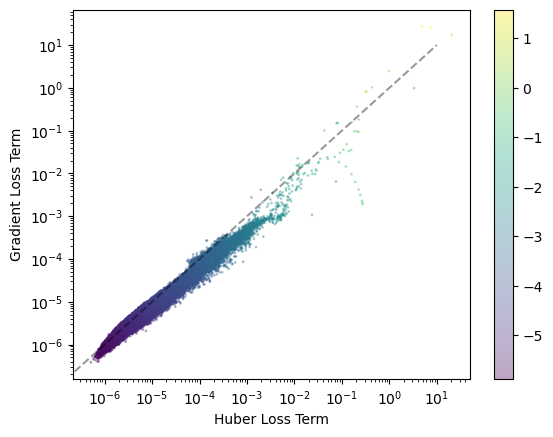

(np.float64(1.5552052788588138e-07), 0.001)

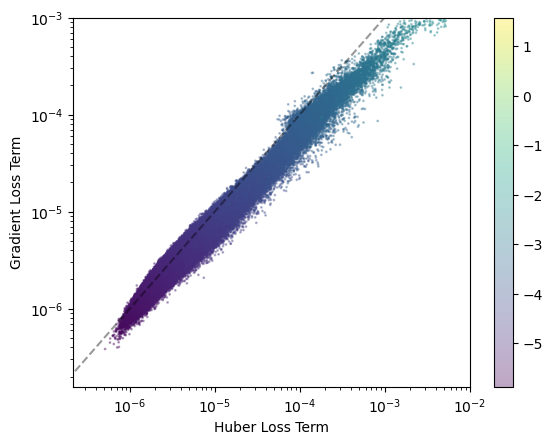

In [295]:
huber_term, grad_term, w = jnp.array(lps).T

plt.scatter(huber_term, grad_term, c=jnp.log10(jnp.array(tlosses)), s=1, alpha=.35)
plt.xlabel('Huber Loss Term')
plt.ylabel('Gradient Loss Term')
plt.colorbar()
plt.loglog()

plt.plot([0, 10], [0, 10], color='k', ls='--', alpha=.4)

display.display(plt.gcf())

plt.xlim(plt.xlim()[0], 1e-2)
plt.ylim(plt.ylim()[0], 1e-3)

Well this looks like a real improvement. For comparison's sake, do the exact same thing but with a huber-only loss

### Huber-only comparison

In [296]:
@eqx.filter_jit
def mean_loss(model, xsp, y, delta=1.0, lambmax=2, lambmin=1, s=.3, lthresh=-4):
    pred_y = jax.vmap(model)(xsp)


    # the factor of 2 is to make the loss more directly comparable to MSE loss
    huber_term = 2 * jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    #grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    #w = jax.nn.sigmoid((lthresh-jnp.log10(huber_term))/s)
    
    return huber_term #+ (w*(lambmax - lambmin) + lambmin) * grad_term

@eqx.filter_jit
def loss_pieces(model, xsp, y, delta=1.0, lambmax=2, lambmin=1., s=.3, lthresh=-4):
    pred_y = jax.vmap(model)(xsp)


    # the factor of 2 is to make the loss more directly comparable to MSE loss
    huber_term = 2 * jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    w = jax.nn.sigmoid((lthresh-jnp.log10(huber_term))/s)
    
    return huber_term, grad_term, w

@eqx.filter_jit
def make_step(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mean_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

Text(0, 0.5, 'LR')

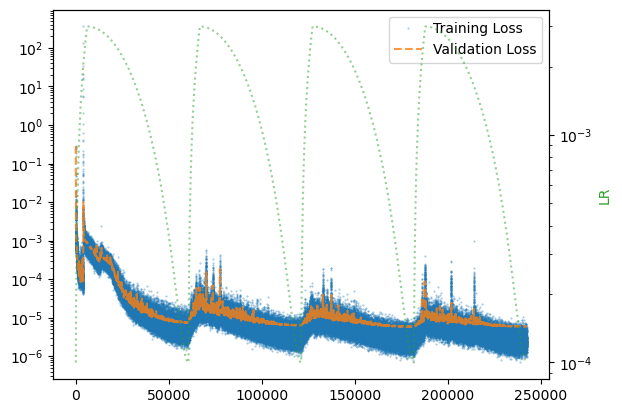

In [297]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = eqx.nn.MLP(3, train_normalized_stellar_models.shape[1], 2048, 3, activation=jax.nn.gelu, key=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lps = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

        lps.append(loss_pieces(model, sparams, sflux))

    vlosses.append(mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

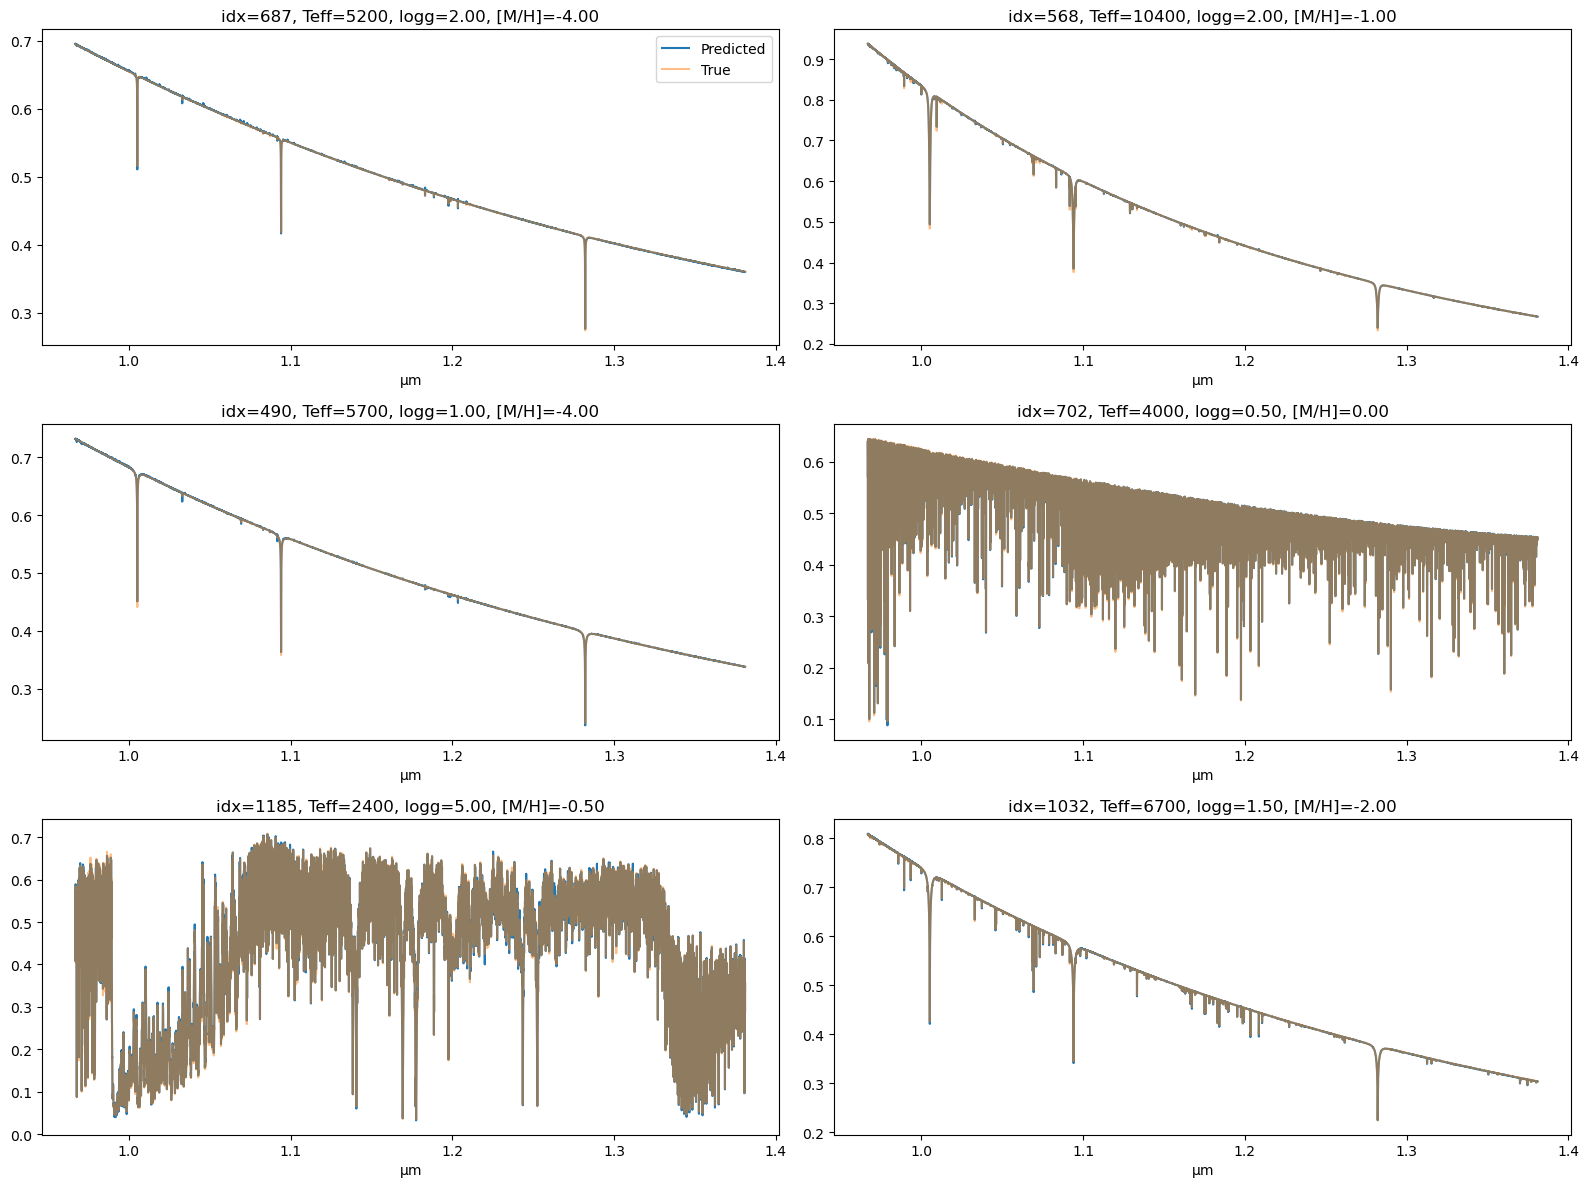

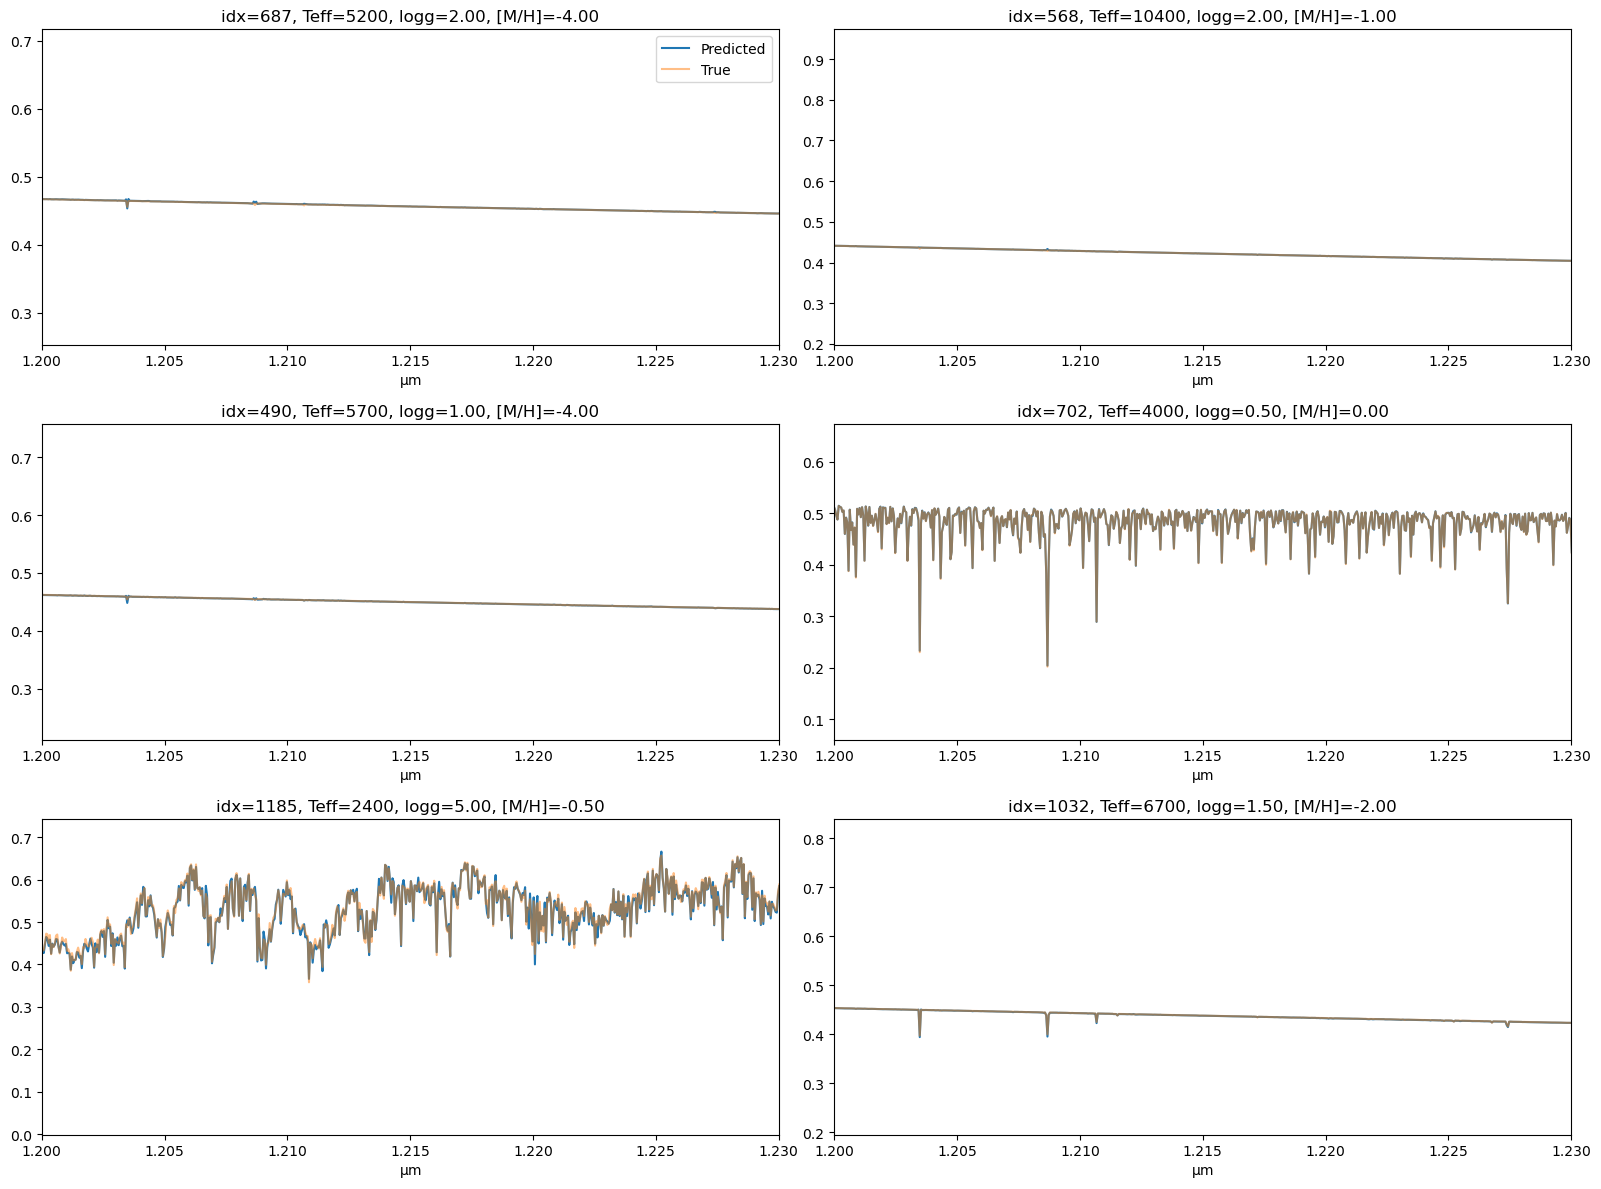

In [298]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel(), label='Predicted')
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5, label='True')
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

axs.ravel()[0].legend(loc=0)
fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

Examine the pieces of the loss separately

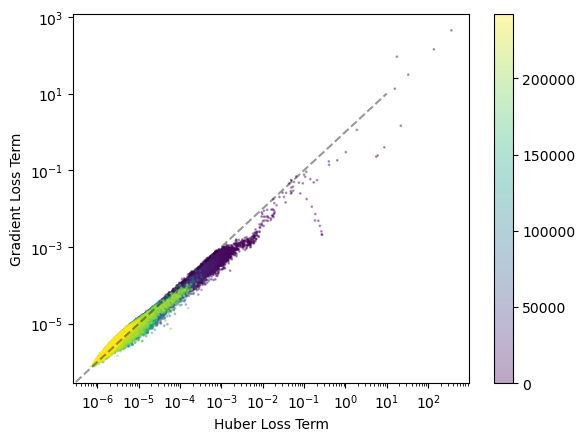

(np.float64(2.795293799559321e-07), 0.001)

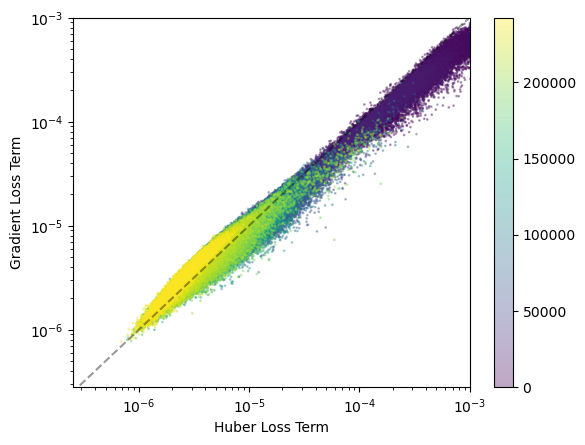

In [ ]:
huber_term, grad_term, w = jnp.array(lps).T

plt.scatter(huber_term, grad_term, c=np.arange(len(huber_term)), s=1, alpha=.35)
plt.xlabel('Huber Loss Term')
plt.ylabel('Gradient Loss Term')
plt.colorbar()
plt.loglog()

plt.plot([0, 10], [0, 10], color='k', ls='--', alpha=.4)

display.display(plt.gcf())
self.layers.append(eqx.nn.Linear(width_size, out_size, key=keys[-1]))

[]

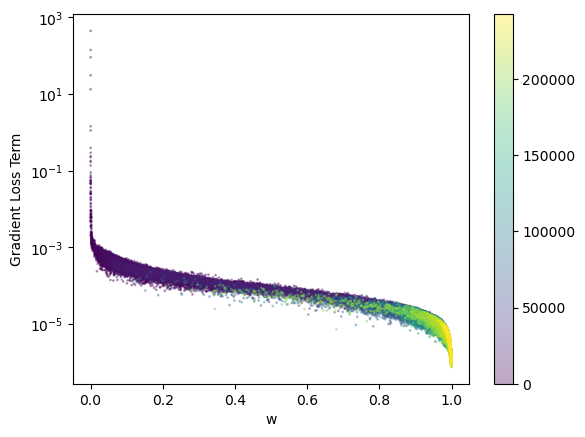

In [300]:
huber_term, grad_term, w = jnp.array(lps).T

plt.scatter(w, grad_term, c=np.arange(len(huber_term)), s=1, alpha=.35)
plt.xlabel('w')
plt.ylabel('Gradient Loss Term')
plt.colorbar()
plt.semilogy()

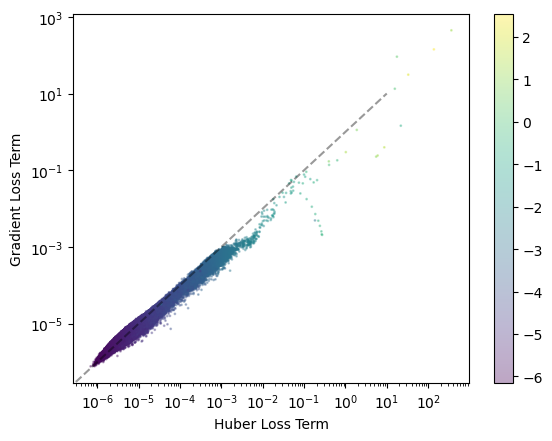

(np.float64(2.795293799559321e-07), 0.001)

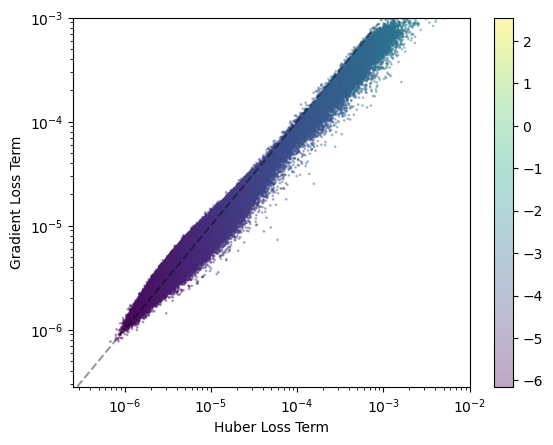

In [ ]:
resampled_micronhuber_term, grad_term, w = jnp.array(lps).T

plt.scatter(huber_term, grad_term, c=jnp.log10(jnp.array(tlosses)), s=1, alpha=.35)
plt.xlabel('Huber Loss Term')
plt.ylabel('Gradient Loss Term')
plt.colorbar()
plt.loglog()

plt.plot([0, 10], [0, 10], color='k', ls='--', alpha=.4)

display.display(plt.gcf())

plt.xlim(plt.xlim()[0], 1e-2)
plt.ylim(plt.ylim()[0], 1e-3)

Ok, so the gradient is pulling it down somewhat relative to if you ignore that.  Good!

# Residuals from a Blackbody

See if there are any improvements from enforcing a blackbody-like form baked into the model.  

In [11]:
PLANCK_EXP_CONSTANT = (cnst.h *cnst.c/(cnst.k_B)).to_value(u.K * u.micron)
resampled_micron = jnp.array(resampled_wave.to_value(u.micron))
planck_exponent = PLANCK_EXP_CONSTANT / resampled_micron

@jax.jit
def bb_flamb_jax(tK):
    unscaled =  resampled_micron**-5. / (jnp.exp(planck_exponent / tK) - 1.0)
    # a clever scaling might be possible using the wien displacement law,
    # but to match the data, just normalize the same way as the data (divide by the median and half)
    return unscaled/jnp.median(unscaled) * 0.5


@jax.jit
def bb_fnu_jax(tK):
    unscaled =  resampled_micron**-3. / (jnp.exp(planck_exponent / tK) - 1.0)
    # a clever scaling might be possible using the wien displacement law,
    # but to match the data, just normalize the same way as the data (divide by the median and half)
    return unscaled/jnp.median(unscaled) * 0.5

In [12]:
class BlackbodyResModel(eqx.Module):
    layers: list
    temp_index: int

    def __init__(self, rkey, 
                       in_size=3,
                       temp_index=0, 
                       #out_size=resampled_micron.shape[0], 
                       width_size=2048, 
                       depth=3, 
                       activation=jax.nn.gelu):
        out_size = resampled_micron.shape[0]

        keys = jax.random.split(rkey, depth+1)

        self.temp_index = temp_index

        self.layers = [eqx.nn.Linear(in_size, width_size, key=keys[0]), activation]
        for i in range(1, depth):
            self.layers.append(eqx.nn.Linear(width_size, width_size, key=keys[i]))
            self.layers.append(activation)
        self.layers.append(eqx.nn.Linear(width_size, out_size, key=keys[-1]))

    def __call__(self, x):
        tK = unscale_stellar_parameters(x)[self.temp_index]
        
        for layer in self.layers:
            x = layer(x)

        return x + bb_flamb_jax(tK)

@eqx.filter_jit
def mean_loss(model, xsp, y, delta=1.0, lambmax=2, lambmin=1, s=.3, lthresh=-4):
    pred_y = jax.vmap(model)(xsp)


    # the factor of 2 is to make the loss more directly comparable to MSE loss
    huber_term = 2 * jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    w = jax.nn.sigmoid((lthresh-jnp.log10(huber_term))/s)
    
    return huber_term + (w*(lambmax - lambmin) + lambmin) * grad_term

@eqx.filter_jit
def loss_pieces(model, xsp, y, delta=1.0, lambmax=2, lambmin=1., s=.3, lthresh=-4):
    pred_y = jax.vmap(model)(xsp)


    # the factor of 2 is to make the loss more directly comparable to MSE loss
    huber_term = 2 * jnp.mean(optax.losses.huber_loss(pred_y, y, delta=delta))
    
    grad_term = jnp.mean((jnp.diff(pred_y, axis=1) - jnp.diff(y, axis=1))**2)

    w = jax.nn.sigmoid((lthresh-jnp.log10(huber_term))/s)
    
    return huber_term, grad_term, w

@eqx.filter_jit
def make_step(model, opt_state, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mean_loss)(model, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/242500 [00:00<?, ?it/s]

E0908 22:54:19.171774   30820 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[1511,2048]{1,0} fusion(mul.39, dynamic_nodonate__first___3_.1), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0908 22:54:19.178292   30820 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0.1 = f32[1511,2048]{1,0} parameter(0)
  parameter_1.1 = f32[2048,2048]{1,0} parameter(1)
  ROOT dot.5 = f32[1511,2048]{1,0} dot(parameter_0.1, parameter_1.1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0908 22:54:23.368970   30821 x

Text(0, 0.5, 'LR')

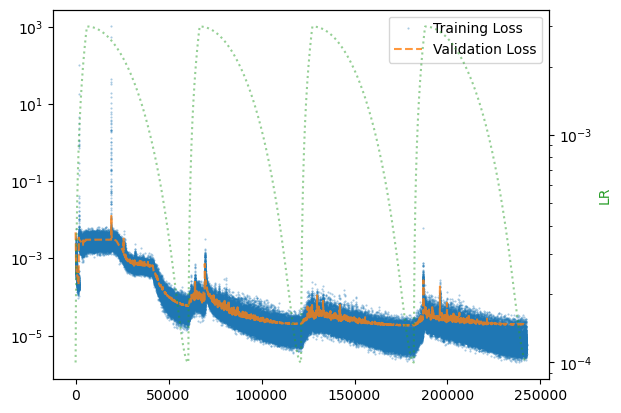

In [13]:
BATCH_SIZE = 64
NEPOCHS = 2500

VALIDATION_SPLIT = 0.2

# necessary if you're fiddling with some of the epoch/cycles/etc
jax.clear_caches()

rkmod, rkepoch, rkvsplit = jax.random.split(jax.random.key(42), 3)  # ensures reproducibility below

nvalid = int(normalized_stellar_models.shape[0] * VALIDATION_SPLIT)
valididx = jax.random.choice(rkvsplit, normalized_stellar_models.shape[0], (nvalid,))


validation_normalized_stellar_models = normalized_stellar_models[valididx]
validation_stellar_parameters_rescaled = stellar_parameters_rescaled[valididx]
train_normalized_stellar_models = jnp.delete(normalized_stellar_models, valididx, axis=0)
train_stellar_parameters_rescaled = jnp.delete(stellar_parameters_rescaled, valididx, axis=0)

nperepoch = int(np.ceil(train_normalized_stellar_models.shape[0] / BATCH_SIZE))
ntot = NEPOCHS*nperepoch

ncycles = 4
single_schedule = optax.schedules.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=3e-3,
    warmup_steps=int(ntot*0.1/ncycles),
    decay_steps=int(ntot/ncycles),
    end_value=1e-4
)
lr_schedule = optax.schedules.join_schedules([single_schedule]*ncycles, ((np.arange(ncycles-1)+1)*ntot/ncycles).astype(int))

model = BlackbodyResModel(rkey=rkmod)

optim = optax.inject_hyperparams(optax.adamw)(learning_rate=lr_schedule)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


t = tqdm(total=ntot)

epoch_boundaries = [0]
vlosses = [mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models)]
tlosses = []
lps = []
lrs = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(train_normalized_stellar_models)))

    for bi in range(nperepoch):
        speci = permorder[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        sflux = train_normalized_stellar_models[speci]
        sparams = train_stellar_parameters_rescaled[speci]

        model, opt_state, loss_value = make_step(model, opt_state, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}, Logvloss: {jnp.log10(vlosses[-1]):.4f}, LR: {opt_state.hyperparams["learning_rate"]:.2e}')
        tlosses.append(loss_value)
        lrs.append(opt_state.hyperparams['learning_rate'])

        lps.append(loss_pieces(model, sparams, sflux))

    vlosses.append(mean_loss(model, validation_stellar_parameters_rescaled, validation_normalized_stellar_models))
    epoch_boundaries.append(len(tlosses))
t.refresh()

plt.semilogy(tlosses,'.', ms=1, alpha=.4, label='Training Loss')
plt.semilogy(epoch_boundaries, vlosses,'--', ms=2, alpha=.8, label='Validation Loss')
plt.legend()
plt.twinx()
plt.semilogy(lrs, color='C2', alpha=.5, ls=':')
plt.ylabel('LR', color='C2')

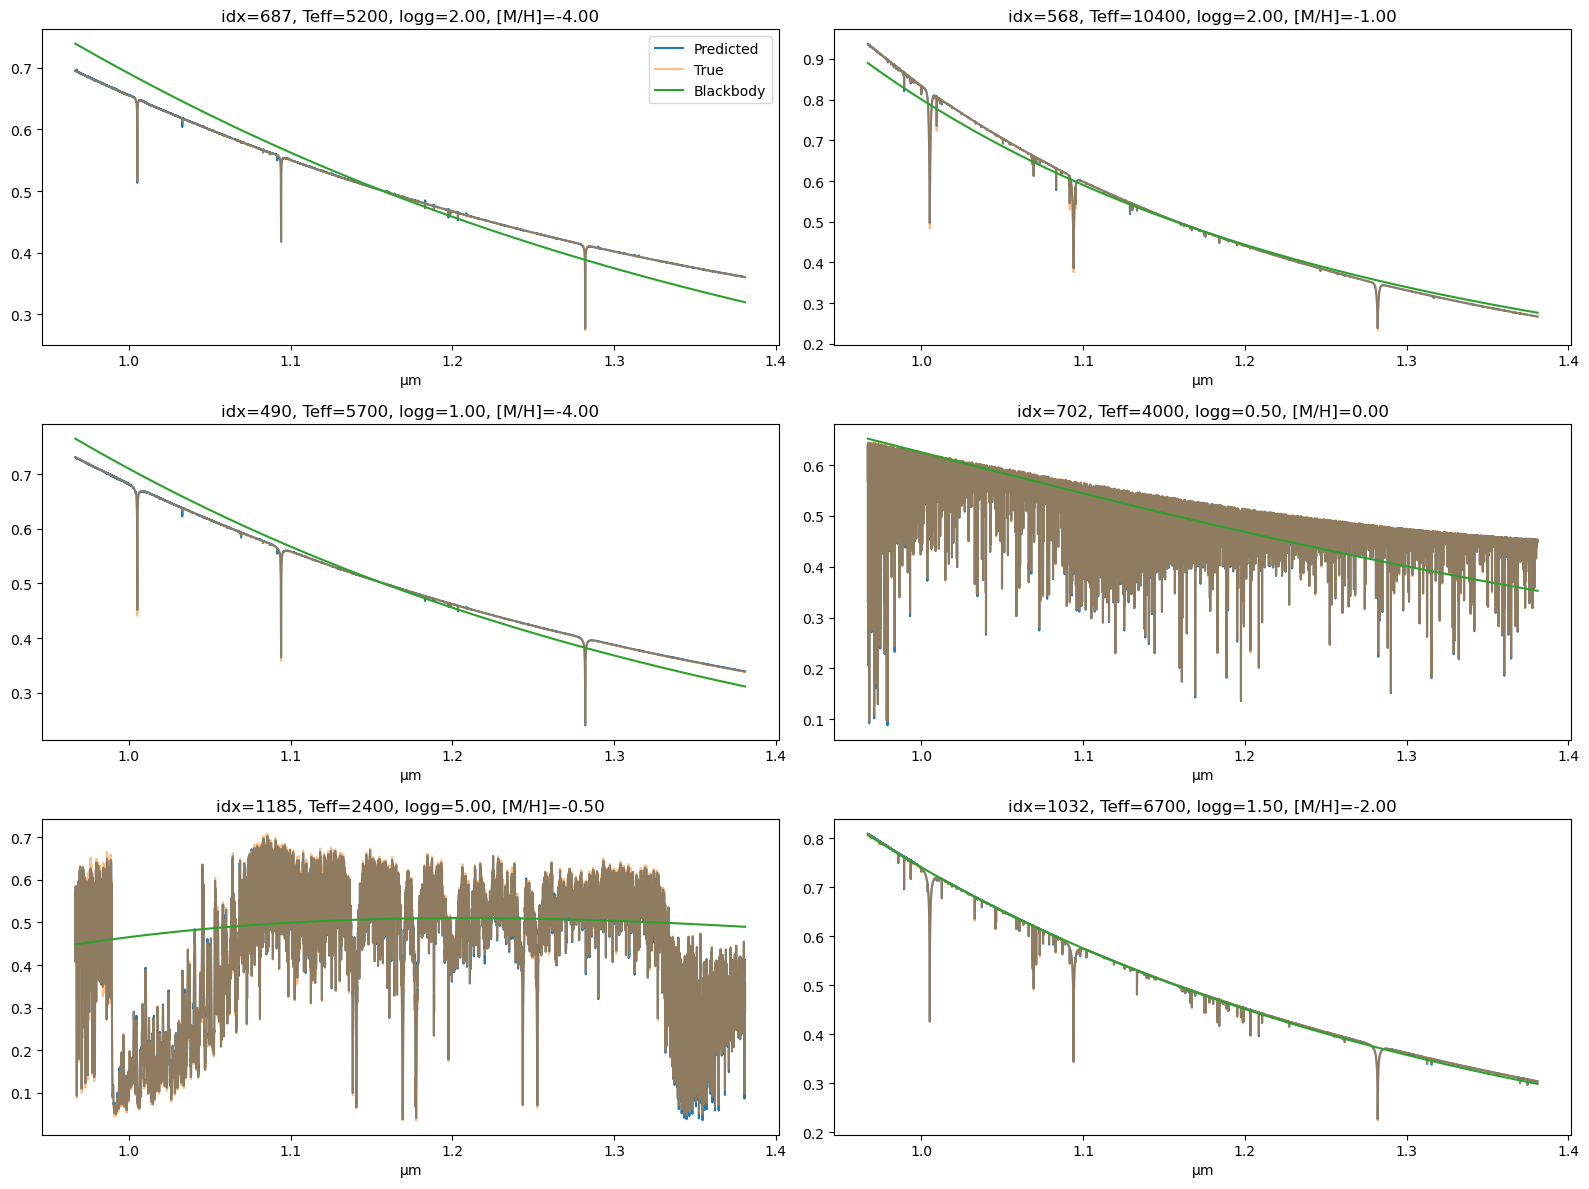

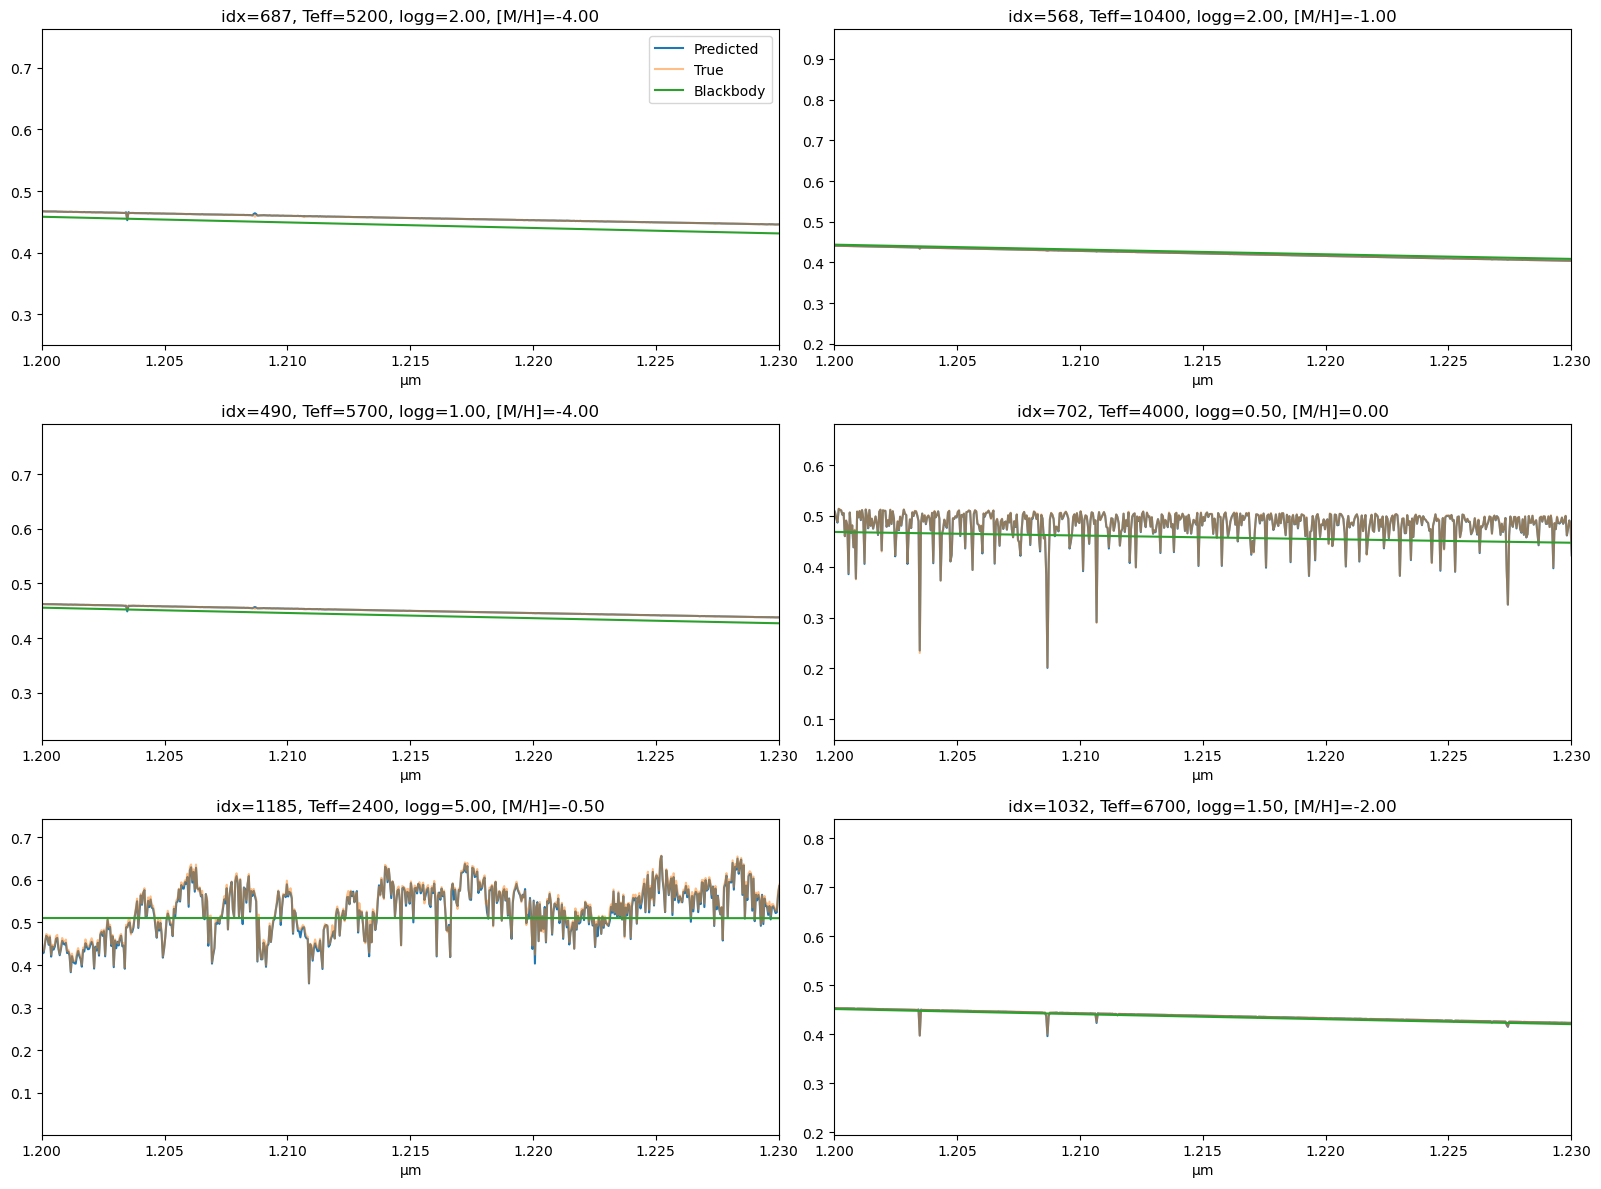

In [14]:
fig, axs = plt.subplots(3, 2, figsize=(16, 12))

idxs = jax.random.choice(jax.random.key(42), validation_stellar_parameters_rescaled.shape[0], (axs.size,))
#idxs = jnp.insert(idxs, 0, sunlike_idx)

for ax, idx in zip(axs.ravel(), idxs):
    pred = model(validation_stellar_parameters_rescaled[idx])
    ax.plot(resampled_wave.to(u.micron), pred.ravel(), label='Predicted')
    ax.plot(resampled_wave.to(u.micron), validation_normalized_stellar_models[idx].ravel(), alpha=.5, label='True')
    bbpred = bb_flamb_jax(unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0])
    ax.plot(resampled_wave.to(u.micron), bbpred.ravel(), label='Blackbody')
    ax.set_title(f"idx={idx}, Teff={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[0]:.0f}, logg={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[1]:.2f}, [M/H]={unscale_stellar_parameters(validation_stellar_parameters_rescaled[idx])[2]:.2f}")

axs.ravel()[0].legend(loc=0)
fig.tight_layout()
display.display(fig)

for ax in axs.ravel():
    ax.set_xlim(1.2,1.23)

Converges much faster apparently...

TODOs (in production): 

1) Re-do with NewEra
2) Confirm fnu vs flamb in model